# Cas d'usage IA : cibler une campagne bancaire de manière responsable

**Auteur** : Étienne Roubaud
**Promo** : Dev-id, Parcours 2 (Pros IT)
**Date début** : 15/09/2026
**Dernière mise à jour** : 08/10/2026

## 0. Imports & configuration

In [1]:
import hashlib
import io
import subprocess
import sys
import time
import warnings
from datetime import datetime

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, classification_report, confusion_matrix, make_scorer,
                             roc_auc_score)
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold, TimeSeriesSplit, cross_val_predict,
                                     cross_val_score, cross_validate, train_test_split)

sys.path.append("..")
import bank
from bank import RANDOM_STATE, SCENARIOS, age_group, build_pipeline, load_data, precision_at_k, psi, rates_by_group

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

## 0.5 Traçabilité de la session

In [2]:
DATASET_NAME = "UCI Bank Marketing, bank-additional-full.csv"
DATASET_SOURCE = "https://archive.ics.uci.edu/dataset/222/bank+marketing"
dataset_sha256 = hashlib.sha256(bank.DATA_PATH.read_bytes()).hexdigest()

try:
    git_commit = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], text=True).strip()
except (subprocess.CalledProcessError, FileNotFoundError):
    git_commit = "unavailable"

print(f"Session date : {datetime.now().isoformat(timespec='minutes')}")
print(f"Python       : {sys.version.split()[0]}")
for lib in [np, pd, sklearn, matplotlib, sns]:
    print(f"{lib.__name__:<13}: {lib.__version__}")
print(f"Git commit   : {git_commit}")
print(f"Dataset      : {DATASET_NAME}")
print(f"Source       : {DATASET_SOURCE}")
print(f"SHA-256      : {dataset_sha256}")

Session date : 2026-10-09T11:04
Python       : 3.12.9
numpy        : 2.5.3
pandas       : 3.0.6
sklearn      : 1.9.1
matplotlib   : 3.11.2
seaborn      : 0.13.2
Git commit   : 5b35a8a
Dataset      : UCI Bank Marketing, bank-additional-full.csv
Source       : https://archive.ics.uci.edu/dataset/222/bank+marketing
SHA-256      : 74adfc578bf77a7ff4bb1ba4a9f8709d9e3c6907342959c2c8416847e0afb4d8


---
## 1. Cadrage métier & problème

**Compétences** : C1 (jeux de données pour besoin métier), C2 (risques éthiques), C4 (choix modèle pertinent)

### 1.1 Contexte client

Une banque de détail démarche ses clients par téléphone pour leur proposer un dépôt à terme. Ces campagnes coûtent cher (temps des conseillers, plateforme d'appels) et rapportent peu : environ un client appelé sur neuf souscrit. Les appels inutiles agacent les clients et dégradent la relation commerciale.

Le centre d'appels ne peut pas joindre tout le monde. La banque veut donc **savoir qui appeler en priorité**, sans discriminer.

### 1.2 Énoncé du problème IA

**Classification binaire supervisée** : prédire si un client souscrira un dépôt à terme (`y`, oui/non) à partir des seules informations **connues avant l'appel**.

### 1.3 Bénéficiaires & impacts

- **Directs** : les conseillers et le responsable de campagne. Ils reçoivent une liste priorisée et passent moins d'appels inutiles.
- **Indirects** : les clients.
  - Ceux qui sont appelés : sollicités, pour une offre pertinente ou non.
  - Ceux qui ne le sont pas : privés d'une offre qui aurait pu les intéresser.

### 1.4 Critères de succès

| Type | Critère | Cible initiale (client) | Cible révisée après EDA | Justification de la révision |
|---|---|---|---|---|
| Métier | Part de souscripteurs parmi les clients appelés (précision dans le top 10 %) | ≥ 2 × le taux de base (≈ 22 %) | Inchangée : ≥ 22,5 % | Taux de base mesuré sur les données : 11,3 % |
| Modèle | PR-AUC, adaptée à une classe positive rare | Nettement au-dessus du taux de base (≈ 0,11) | ≥ 0,23, le double du taux de base mesuré (0,113) | Même exigence que la cible métier. Une PR-AUC égale au taux de base correspond à un classement au hasard |
| Opérationnel | Temps de réponse de l'API | < 200 ms | Inchangée | L'EDA ne change rien à la latence |

### 1.5 Risques éthiques & réglementaires anticipés

| Risque | Origine | Réponse prévue |
|---|---|---|
| **Ciblage discriminant** | Âge, métier, situation familiale, éducation, crédit en défaut. L'âge, la situation de famille et la vulnérabilité économique font partie des critères de discrimination de l'art. 225-1 du Code pénal | Les retirer dans un scénario dédié, puis mesurer l'effet. Proxies à surveiller : retraité, étudiant |
| **Données personnelles** | Profil client et données financières (prêts, défaut de paiement). Aucune catégorie particulière au sens de l'art. 9 du RGPD | Minimisation, information des clients, droit d'opposition (art. 21), durée de conservation, AIPD probable |
| **Démarchage** | Loi 2025-594 : consentement préalable depuis le 11/08/2026, sauf appel lié à un contrat en cours | Filtre consentement / opposition avant le scoring. Base légale validée par le DPO |
| **AI Act** | Le ciblage marketing ne figure pas à l'annexe III, contrairement à l'évaluation de solvabilité | Risque minimal ou limité. Transparence et supervision humaine malgré tout |

### 1.6 Synthèse cadrage

Le problème : prioriser une liste d'appels de capacité limitée. La tâche : une classification binaire qui produit une probabilité de souscription, à partir des seules données connues avant l'appel. Le critère dominant : la part de souscripteurs parmi les 10 % de clients appelés, au moins le double du taux de base. Le principal risque : un ciblage discriminant fondé sur l'âge ou le métier, à mesurer et à neutraliser sans perdre en performance.

---
## 2. Identification & acquisition des données

**Compétences** : C1 (identifier un jeu de données pertinent et cohérent)

### 2.1 Sources

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---|---|---|---|
| UCI Machine Learning Repository, Bank Marketing (`bank-additional-full.csv`) | Campagnes d'appels d'une banque portugaise, de mai 2008 à novembre 2010 | 41 188 lignes, 21 colonnes | CSV, séparateur `;` | Public, licence CC BY 4.0 (attribution : Moro, Cortez et Rita, 2014) | 01/10/2026 |

### 2.2 Chargement

In [3]:
raw = pd.read_csv(bank.DATA_PATH, sep=";")
raw.shape

(41188, 21)

### 2.3 Dictionnaire de variables

| Variable | Description | Type | Plage / valeurs | Connue avant l'appel ? | Cible ? | Sensible ? |
|---|---|---|---|---|---|---|
| `age` | Âge du client | num | 17 à 98 | oui | non | oui |
| `job` | Métier | cat | 12 modalités, dont `unknown` | oui | non | oui |
| `marital` | Situation familiale (`divorced` inclut le veuvage) | cat | 4 modalités, dont `unknown` | oui | non | oui |
| `education` | Niveau d'études | cat | 8 modalités, dont `unknown` | oui | non | oui |
| `default` | Crédit en défaut | cat | no, yes, unknown | oui | non | à discuter (fragilité financière) |
| `housing` | Prêt immobilier | cat | no, yes, unknown | oui | non | non |
| `loan` | Prêt personnel | cat | no, yes, unknown | oui | non | non |
| `contact` | Type de téléphone du dernier contact | cat | cellular, telephone | oui | non | non |
| `month` | Mois du dernier contact | cat | 10 modalités (ni janvier ni février) | oui | non | non |
| `day_of_week` | Jour du dernier contact | cat | du lundi au vendredi | oui | non | non |
| `duration` | Durée du dernier appel, en secondes | num | 0 à 4 918 | **non**, connue une fois l'appel terminé | non | non |
| `campaign` | Nombre de contacts pendant cette campagne, dernier inclus | num | 1 à 56 | oui (on sait combien d'appels ont déjà été passés) | non | non |
| `pdays` | Jours écoulés depuis un contact d'une campagne précédente | num | 0 à 27, ou 999 = jamais contacté | oui | non | non |
| `previous` | Nombre de contacts avant cette campagne | num | 0 à 7 | oui | non | non |
| `poutcome` | Résultat de la campagne précédente | cat | failure, nonexistent, success | oui | non | non |
| `emp.var.rate` | Taux de variation de l'emploi (trimestriel) | num | -3,4 à 1,4 | oui | non | non |
| `cons.price.idx` | Indice des prix à la consommation (mensuel) | num | 92,2 à 94,8 | oui | non | non |
| `cons.conf.idx` | Indice de confiance des consommateurs (mensuel) | num | -50,8 à -26,9 | oui | non | non |
| `euribor3m` | Euribor à 3 mois (journalier) | num | 0,63 à 5,05 | oui | non | non |
| `nr.employed` | Nombre de salariés (trimestriel) | num | 4 964 à 5 228 | oui | non | non |
| `y` | A souscrit un dépôt à terme | cat | yes, no | sans objet | **oui** | non |

### 2.4 Synthèse acquisition

Un fichier public unique : 41 188 appels d'une banque portugaise entre mai 2008 et novembre 2010, dans l'ordre chronologique. Aucune valeur manquante au sens de pandas, mais des modalités `unknown`. Deux points dès cette étape : `duration` n'est connue qu'après l'appel, donc inutilisable pour décider qui appeler, et cinq variables personnelles (âge, métier, situation familiale, éducation, crédit en défaut) peuvent porter un ciblage discriminant.

---
## 3. Exploration & analyse des données (EDA)

**Compétences** : C2 (risques éthiques détectables dans la donnée), C3 (préparation des données)

### 3.1 Premier coup d'œil

In [4]:
raw.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### 3.2 Qualité des données

In [5]:
print("Missing values:", raw.isna().sum().sum())
print("Duplicates:", raw.duplicated().sum())

Missing values: 0
Duplicates: 12


In [6]:
(raw == "unknown").sum().loc[lambda s: s > 0]

job           330
marital        80
education    1731
default      8597
housing       990
loan          990
dtype: int64

In [7]:
raw["default"].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

In [8]:
(raw["pdays"] == 999).mean().round(3)

np.float64(0.963)

In [9]:
pd.crosstab(raw["poutcome"] == "nonexistent", raw["previous"] == 0)

previous,False,True
poutcome,,
False,5625,0
True,0,35563


In [10]:
raw.loc[raw["duration"] == 0, "y"].value_counts()

y
no    4
Name: count, dtype: int64

- **12 doublons**, aucun manquant. Les doublons sont supprimés au chargement (`load_data`), avant le split, pour qu'une même ligne ne se retrouve pas à la fois dans le train et dans le test.
- Les `unknown` forment une vraie modalité : on les garde comme catégorie.
- `default` n'a que **3 « yes »** : la variable est presque constante, son seul signal possible est `unknown`.
- `pdays = 999` sur **96,3 %** des lignes : 999 est un code qui veut dire « jamais contacté ». Le pipeline le transforme en indicateur 0/1.
- `poutcome = nonexistent` équivaut exactement à `previous = 0` : pour les clients jamais contactés, les deux colonnes disent la même chose. Pour les autres, `previous` donne le nombre de contacts passés et `poutcome` le résultat de la dernière campagne.
- `duration = 0` donne toujours « no » : la durée de l'appel contient la réponse. C'est une fuite d'information.

In [11]:
df = load_data()
df.shape

(41176, 21)

### 3.3 Distribution des variables

In [12]:
raw.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


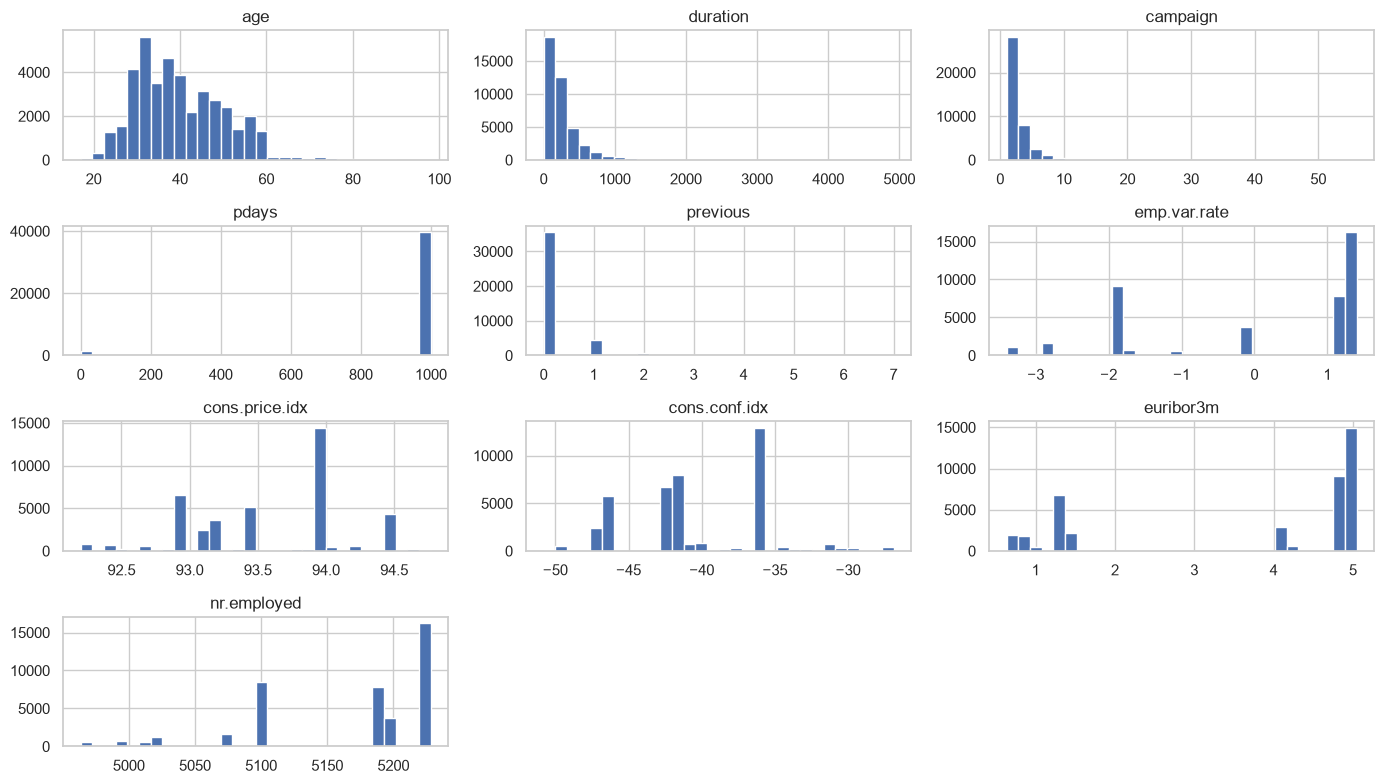

In [13]:
raw.hist(figsize=(14, 8), bins=30)
plt.tight_layout()
plt.show()

### 3.4 Variable cible

In [14]:
df["y"].value_counts(normalize=True).round(3)

y
0    0.887
1    0.113
Name: proportion, dtype: float64

**11,3 % de « yes »**. Un modèle qui répond toujours « non » obtient 88,7 % d'accuracy sans rien apprendre. L'accuracy est donc écartée au profit de métriques centrées sur la classe positive.

### 3.5 Relations entre variables : l'effet du temps

In [15]:
decile = np.arange(len(df)) * 10 // len(df) + 1
by_decile = df.groupby(decile).agg(subscription_rate=("y", "mean"), euribor=("euribor3m", "mean"))
by_decile.round(3).T

,1,2,3,4,5,6,7,8,9,10
subscription_rate,0.028,0.035,0.042,0.066,0.062,0.055,0.102,0.120,0.157,0.460
euribor,4.857,4.859,4.941,4.961,4.965,4.845,3.370,1.354,1.260,0.802


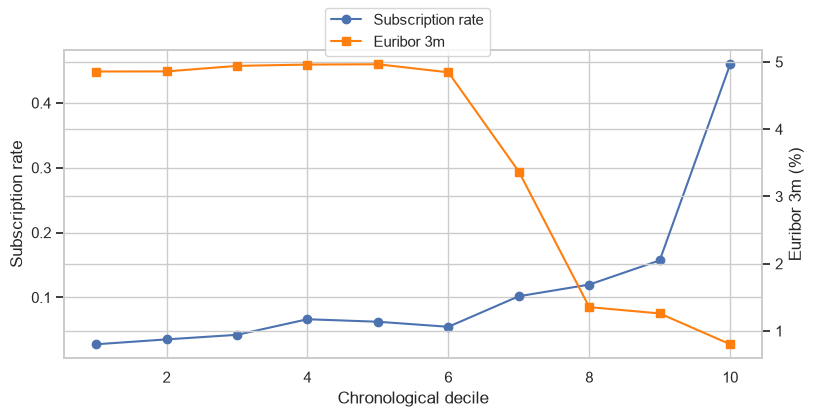

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(by_decile.index, by_decile["subscription_rate"], marker="o", label="Subscription rate")
ax.set_xlabel("Chronological decile")
ax.set_ylabel("Subscription rate")
ax2 = ax.twinx()
ax2.plot(by_decile.index, by_decile["euribor"], marker="s", color="tab:orange", label="Euribor 3m")
ax2.set_ylabel("Euribor 3m (%)")
fig.legend(loc="upper center")
plt.show()

Les lignes sont dans l'ordre chronologique. D'un décile à l'autre, le taux de souscription passe de **2,8 % à 46 %** pendant que l'Euribor tombe de **4,86 à 0,80** : c'est la crise de 2008. Les variables macroéconomiques encodent la période. Conséquences : un test de robustesse dans le temps (entraîner sur le passé, tester sur la période récente) et une dérive à surveiller en production.

### 3.6 Analyse des biais & variables sensibles

Taux de souscription et effectifs par tranche d'âge, métier, situation familiale et niveau d'études.

In [17]:
df.groupby(age_group(df["age"]), observed=True)["y"].agg(["count", "mean"]).round(3)

,count,mean
age,,
<30,5667,0.163
30-44,22579,0.096
45-59,11738,0.092
60+,1192,0.396


In [18]:
for col in ["job", "marital", "education"]:
    display(df.groupby(col)["y"].agg(["count", "mean"]).sort_values("mean").round(3))

,count,mean
job,,
blue-collar,9253,0.069
services,3967,0.081
entrepreneur,1456,0.085
housemaid,1060,0.100
self-employed,1421,0.105
technician,6739,0.108
unknown,330,0.112
management,2924,0.112
admin.,10419,0.130


,count,mean
marital,,
married,24921,0.102
divorced,4611,0.103
single,11564,0.140
unknown,80,0.150


,count,mean
education,,
basic.9y,6045,0.078
basic.6y,2291,0.082
basic.4y,4176,0.102
high.school,9512,0.108
professional.course,5240,0.114
university.degree,12164,0.137
unknown,1730,0.145
illiterate,18,0.222


La cible est très inégale selon les groupes :
- **âge** : 39,6 % chez les 60 ans et plus, contre 9 à 10 % entre 30 et 59 ans ;
- **métier** : 31,4 % chez les étudiants et 25,3 % chez les retraités, contre 6,9 % chez les ouvriers ;
- situation familiale et éducation : écarts plus faibles (8 à 14 %, hors petits effectifs).

Un modèle qui apprend ces écarts appellera surtout les seniors et les étudiants, et très peu les ouvriers. On mesurera, en comparant les scénarios avec et sans ces variables, qui est appelé et qui est oublié (taux d'appel, faux négatifs par groupe). Les petits effectifs (`illiterate` : 18 clients) ne permettent aucune conclusion.

### 3.7 Synthèse EDA

1. **Qualité** : 12 doublons supprimés, aucun manquant, des `unknown` gardés comme modalité, `pdays = 999` transformé en indicateur « jamais contacté », `default` quasi constant.
2. **Fuite** : `duration` n'est connue qu'après l'appel, et `duration = 0` donne toujours « no ». On la garde seulement dans un premier scénario de référence, pour mesurer l'effet de la fuite, puis on la retire.
3. **Déséquilibre** : 11,3 % de « yes ». Accuracy écartée : PR-AUC et précision dans le top 10 %.
4. **Temps** : le taux de souscription passe de 2,8 % à 46 % et les variables macro portent la période. Robustesse temporelle à tester, dérive à surveiller.
5. **Biais** : les 60 ans et plus et les étudiants souscrivent 4 à 6 fois plus que les ouvriers. Risque de ciblage par l'âge et le métier, à mesurer groupe par groupe sur les prédictions du modèle.

**Révision des critères de succès** : le taux de base mesuré (11,3 %) confirme la cible métier, au moins 22,5 % de souscripteurs dans le top 10 %, et chiffre la cible du modèle : une PR-AUC d'au moins 0,23, le double du hasard.

---
## 4. Préparation des données

**Compétences** : C3 (préparer les données pour renforcer intégrité et pertinence)

### 4.1 Découpage train / test

In [19]:
X, y = df.drop(columns="y"), df["y"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
pd.DataFrame({"rows": [len(y_train), len(y_test)], "subscription_rate": [y_train.mean(), y_test.mean()]},
             index=["train", "test"]).round(3)

,rows,subscription_rate
train,32940,0.113
test,8236,0.113


20 % des clients sont mis de côté pour le test final, avec le même taux de « yes » que le train grâce au découpage stratifié. Ce test reste scellé : il ne servira qu'une fois, pour évaluer le modèle retenu. Toutes les comparaisons se font en validation croisée sur le train.

### 4.2 Recette de préparation

La recette est écrite une seule fois, dans `bank.py` (`build_pipeline`), et sert partout : notebook, script d'entraînement, API et tests. Elle reçoit la liste des variables du scénario et ne prépare que celles-là :
- **variables numériques** : mises à la même échelle (`StandardScaler`) ;
- **`pdays`** : 999 veut dire « jamais contacté ». Cette valeur est remplacée par la médiane des vrais délais, et une colonne 0/1 « jamais contacté » est ajoutée ;
- **variables catégorielles** : encodage one-hot. Une modalité jamais vue à l'entraînement est ignorée au lieu de faire échouer la prédiction ;
- **pas d'autre imputation** : le jeu n'a aucune valeur manquante, et les `unknown` restent une modalité.

Rien n'est ajusté à cette étape. La recette est ajustée dans le pipeline complet, sur la partie entraînement de chaque pli de validation croisée : les données de validation ne fuient pas dans la préparation.

Exemple : la recette appliquée au scénario sans variables sensibles, avec une régression logistique.

In [20]:
build_pipeline(SCENARIOS["S3"], LogisticRegression(max_iter=1000))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preparation', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('pdays', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3

### 4.3 Scénarios de jeux de données

Chaque scénario retire un groupe de variables au précédent. La recette reste la même, seul le périmètre change : on ne fait varier qu'un facteur à la fois.

| Scénario | Variables retirées | Variables restantes | Pourquoi |
|---|---|---|---|
| **S1** référence | aucune | 20 | Point de comparaison. Il contient `duration`, connue seulement après l'appel : son score est gonflé artificiellement et sert à mesurer l'effet de cette fuite. |
| **S2** sans fuite | `duration` | 19 | La durée de l'appel n'est connue qu'une fois l'appel terminé : on ne peut pas s'en servir pour décider qui appeler. C'est la vraie référence. |
| **S3** sans variables sensibles | en plus : `age`, `job`, `marital`, `education`, `default` | 14 | Éviter un ciblage discriminant (détail ci-dessous). |
| **S4** minimal | en plus : `campaign`, `pdays`, `previous`, `poutcome` | 10 | Sans l'historique des campagnes : le modèle tient-il avec les prêts du client, le contexte de l'appel et la conjoncture ? |

**Pourquoi retirer chaque variable sensible :**

| Variable | Argument |
|---|---|
| `age` | Critère de discrimination interdit par l'art. 225-1 du Code pénal. Avec l'âge, le modèle appellerait surtout les 60 ans et plus (39,6 % de souscription, contre 9 à 10 % entre 30 et 59 ans). |
| `marital` | La « situation de famille » est un critère interdit par le même article. De plus, `divorced` inclut les personnes veuves : c'est une information sur un deuil. |
| `job` | Le métier révèle le statut social et trahit l'âge (`retired`, `student`) ou la précarité (`unemployed`, `housemaid`). |
| `education` | Reflète le niveau socio-économique, sans lien légitime avec la capacité à épargner. |
| `default` | Crédit en défaut : la « particulière vulnérabilité résultant de la situation économique » est aussi un critère de l'art. 225-1. Et elle n'apporte rien au modèle (mesure ci-dessous) : le RGPD demande de ne garder que les données utiles. |

Les variables retirées restent dans les données pour mesurer l'équité groupe par groupe.

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, features in {"with default": SCENARIOS["S3"] + ["default"], "without default": SCENARIOS["S3"]}.items():
    scores = cross_val_score(build_pipeline(features, LogisticRegression(max_iter=1000)), X_train, y_train,
                             cv=cv, scoring="average_precision")
    print(f"{name:<16} PR-AUC {scores.mean():.3f} +- {scores.std():.3f}")

with default     PR-AUC 0.451 +- 0.014


without default  PR-AUC 0.451 +- 0.014


Même PR-AUC avec et sans `default` : la retirer ne coûte rien.

### 4.4 Synthèse préparation

- **Recette unique** : `build_pipeline` sert au notebook, à l'entraînement, à l'API et aux tests. Même préparation partout, ajustée seulement sur les données d'entraînement.
- **Quatre scénarios** : chacun retire un groupe de variables au précédent, la recette ne change pas.
- **`default` retirée** avec les variables sensibles : elle touche à la vulnérabilité économique et n'apporte rien au modèle (PR-AUC 0,451 avec ou sans).
- **Test scellé** : 20 % des clients, stratifié, `random_state = 42`. Il ne servira qu'une fois.

### 4.5 Assertions de qualité

In [22]:
assert df.duplicated().sum() == 0, "Duplicate rows left"
assert set(df["y"].unique()) == {0, 1}, "Binary target expected"
assert len(X_train) + len(X_test) == len(df), "Incomplete split"
assert abs(y_train.mean() - y_test.mean()) < 0.005, "Split is not stratified"
assert "duration" not in SCENARIOS["S2"], "Leaking variable in S2"
assert not set(bank.SENSITIVE) & set(SCENARIOS["S3"]), "Sensitive variable in S3"
print("All quality checks passed")

All quality checks passed


---
## 5. Modélisation & entraînement

**Compétences** : C4 (choisir un modèle adapté), C5 (entraîner le modèle)

### 5.0 Familles de modèles candidates

**Qualification du cas**, avant de regarder le moindre modèle :

| Question | Réponse |
|---|---|
| Volume de données exploitables | 1 k à 100 k : 32 940 clients d'entraînement, 14 variables une fois la fuite et les variables sensibles retirées |
| Nature du signal | Non linéaire faible : l'EDA montre surtout des relations monotones (Euribor, historique de contact) |
| Contraintes dures | Données personnelles (RGPD) ; pas d'appel à un service externe (données bancaires) ; latence < 200 ms |
| Budget | Entraînement et inférence quasi nuls |
| Réentraînement | Sur déclenchement (dérive ou écart de calibration), vérifié après chaque campagne |

| Famille | Adaptée à mon problème ? | Coût total (train + inférence) | Explicabilité | Dépendance fournisseur | Décision |
|---|---|---|---|---|---|
| ML classique (scikit-learn) | Oui : un tableau de 41 176 lignes et 20 colonnes | Faible | Élevée (linéaire) à moyenne (ensembles) | Aucune | **Retenue** |
| Deep Learning | Possible, mais sur un tableau de cette taille les arbres et le boosting font aussi bien | Élevé | Faible | Aucune | Écartée : aucun gain attendu, explicabilité faible |
| SLM local | Non : aucun texte à générer | Moyen | Moyenne | Aucune | Écartée : pas de tâche de génération |
| LLM API + RAG | Non : aucun corpus documentaire | Élevé (facturé à la requête) | Faible | Forte | Écartée : données bancaires envoyées à un tiers, coût par client, aucun gain sur un tableau |
| Architecture agentique | Non : aucune action à enchaîner | Très élevé | Très faible | Forte | Écartée : rien à orchestrer |

### 5.0.1 Synthèse familles

Le ML classique est retenu : les données sont un tableau, le conseiller a besoin de probabilités fiables et d'une explication, et le coût doit rester quasi nul. Les autres familles sont écartées parce qu'il n'y a ni texte, ni image, ni corpus, et qu'envoyer des données bancaires à une API externe poserait un problème RGPD. Contrainte décisive : les données personnelles et l'explicabilité.

### 5.1 Modèles candidats

| Modèle | Famille | Pourquoi candidat ? | Coût (entraînement / inférence) | Explicabilité |
|---|---|---|---|---|
| Plancher (`DummyClassifier`) | aucune | Repère : il annonce toujours le taux moyen. Un modèle doit faire mieux | nul / nul | totale |
| Régression logistique | linéaire | Référence imposée par le sujet, probabilités bien calibrées, lisible | faible / faible | élevée (coefficients) |
| Forêt aléatoire | ensemble (bagging) | Demandée par le sujet (« arbre de décision ou forêt »), robuste, capte les interactions | moyen / moyen | moyenne |
| Boosting (`HistGradientBoostingClassifier`) | ensemble (boosting) | Souvent le plus performant sur des données en tableau | faible / faible | moyenne |

L'arbre de décision seul n'est pas retenu : le sujet demande un arbre ou une forêt, la forêt est un ensemble d'arbres plus robuste, et 3 candidats suffisent pour garder une comparaison lisible. Le coût réel est mesuré plus bas.

### 5.2 Entraînement & validation croisée

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models = {
    "Dummy (floor)": DummyClassifier(strategy="prior"),
    "Logistic regression": LogisticRegression(max_iter=1000),
    "Random forest": RandomForestClassifier(n_estimators=200, min_samples_leaf=10, n_jobs=-1,
                                            random_state=RANDOM_STATE),
    "Gradient boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}
metrics = {"PR-AUC": "average_precision", "ROC-AUC": "roc_auc",
           "Precision top 10%": make_scorer(precision_at_k, response_method="predict_proba")}
rows = []
for scenario, features in SCENARIOS.items():
    for name, model in models.items():
        scores = cross_validate(build_pipeline(features, model), X_train, y_train, cv=cv, scoring=metrics,
                                return_train_score=True)
        rows.append({"Scenario": scenario, "Model": name,
                     **{m: scores[f"test_{m}"].mean() for m in metrics},
                     "PR-AUC std": scores["test_PR-AUC"].std(),
                     "PR-AUC train": scores["train_PR-AUC"].mean(),
                     "Fit time (s)": scores["fit_time"].mean()})
results = pd.DataFrame(rows)

### 5.3 Métriques retenues & justification

- **Découpage** : `StratifiedKFold` à 5 plis. Chaque pli garde 11,3 % de « yes », et les mêmes plis servent à tous les couples scénario × modèle : la comparaison est valable. On donne la moyenne et l'écart-type.
- **Métrique principale : PR-AUC.** Elle ne regarde que la classe rare, celle qui compte, et ne dépend pas d'un seuil. Au hasard, elle vaut 0,113.
- **Métrique métier : précision dans le top 10 %.** Le centre d'appels appelle les 10 % de clients les mieux notés : sur 100 appels, combien de souscripteurs ? Critère de succès : au moins 22,5.
- **Métrique secondaire : ROC-AUC**, demandée par le sujet. Elle est flatteuse quand les « non » sont nombreux.
- **Pourquoi pas le F1 macro en principal**, souvent utilisé quand une classe est rare : le F1 dépend d'un seuil, et notre seuil est fixé par la capacité d'appel. Précision, rappel, F1 et matrice de confusion sont donnés au test final, au seuil retenu.
- **Accuracy écartée** : un modèle qui répond toujours « non » obtient 88,7 %.

### 5.4 Comparaison des modèles

In [24]:
results.round(3)

,Scenario,Model,PR-AUC,ROC-AUC,Precision top 10%,PR-AUC std,PR-AUC train,Fit time (s)
0,S1,Dummy (floor),0.113,0.500,0.123,0.000,0.113,0.112
1,S1,Logistic regression,0.598,0.934,0.616,0.015,0.602,0.292
2,S1,Random forest,0.659,0.945,0.639,0.016,0.782,0.997
3,S1,Gradient boosting,0.666,0.949,0.645,0.013,0.780,0.559
4,S2,Dummy (floor),0.113,0.500,0.123,0.000,0.113,0.132
5,S2,Logistic regression,0.451,0.790,0.488,0.014,0.458,0.332
6,S2,Random forest,0.467,0.797,0.513,0.015,0.600,0.947
7,S2,Gradient boosting,0.461,0.799,0.510,0.015,0.558,0.440
8,S3,Dummy (floor),0.113,0.500,0.123,0.000,0.113,0.088
9,S3,Logistic regression,0.451,0.790,0.492,0.014,0.454,0.234


- **Plancher** : 0,113 de PR-AUC et 12 souscripteurs pour 100 appels. Tous les modèles font 3 à 6 fois mieux.
- **Fuite** : avec `duration`, la PR-AUC monte à 0,60-0,67 et la ROC-AUC à 0,93-0,95. Sans elle, 0,45-0,47 et 0,79-0,80. La durée de l'appel n'est connue qu'une fois l'appel terminé : ce score est gonflé artificiellement, la vraie référence est le scénario sans fuite.
- **Variables sensibles** : les retirer ne coûte rien (régression logistique : 0,451 avec ou sans). **Scénario retenu : S3, sans variables sensibles.**
- **Historique des campagnes** : le retirer coûte 0,05 à 0,06 de PR-AUC. Il porte un vrai signal.
- **Modèles** : la forêt et le boosting dépassent un peu la régression (0,466 et 0,468 contre 0,451), mais leur score sur le train est bien plus haut que sur la validation (0,545 et 0,539 contre 0,454) : ils apprennent en partie par cœur.

L'écart entre modèles est-il réel ? Comparaison pli par pli sur le scénario retenu, 5 plis répétés 3 fois :

In [25]:
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
candidates = ["Logistic regression", "Random forest", "Gradient boosting"]
paired = {name: cross_validate(build_pipeline(SCENARIOS["S3"], models[name]), X_train, y_train, cv=rcv,
                               scoring=metrics)
          for name in candidates}
for name in candidates[1:]:
    for metric in ["PR-AUC", "Precision top 10%"]:
        gap = paired[name][f"test_{metric}"] - paired["Logistic regression"][f"test_{metric}"]
        print(f"{name} vs logistic regression, {metric}: {gap.mean():+.3f}, better on {(gap > 0).sum()}/{len(gap)} folds")

Random forest vs logistic regression, PR-AUC: +0.015, better on 15/15 folds
Random forest vs logistic regression, Precision top 10%: +0.022, better on 14/15 folds
Gradient boosting vs logistic regression, PR-AUC: +0.016, better on 15/15 folds
Gradient boosting vs logistic regression, Precision top 10%: +0.018, better on 15/15 folds


La forêt et le boosting battent la régression sur presque tous les plis, d'environ +0,015 de PR-AUC : l'écart est petit mais réel. En métier, cela fait environ 2 souscripteurs de plus pour 100 appels.

Mais les données changent beaucoup dans le temps. Test de robustesse temporelle : on entraîne sur le passé et on teste sur la période suivante, 5 fois, **à l'intérieur du train** (le test reste scellé) :

In [26]:
warnings.filterwarnings("ignore", message="Skipping features without any observed values")
ordered = X_train.sort_index()
y_ordered = y_train.loc[ordered.index]
rows = []
for name in candidates:
    for fold, (past, future) in enumerate(TimeSeriesSplit(n_splits=5).split(ordered), start=1):
        model = build_pipeline(SCENARIOS["S3"], models[name]).fit(ordered.iloc[past], y_ordered.iloc[past])
        proba = model.predict_proba(ordered.iloc[future])[:, 1]
        rows.append({"Model": name, "Fold": fold, "Subscription rate": y_ordered.iloc[future].mean(),
                     "ROC-AUC": roc_auc_score(y_ordered.iloc[future], proba),
                     "Precision top 10%": precision_at_k(y_ordered.iloc[future], proba)})
temporal = pd.DataFrame(rows)
print("Subscription rate by fold:", temporal.groupby("Fold")["Subscription rate"].first().round(3).to_dict())
by_fold = temporal.pivot(index="Fold", columns="Model", values=["ROC-AUC", "Precision top 10%"])
by_fold.loc["Mean"] = by_fold.mean()
by_fold.round(3)

Subscription rate by fold: {1: 0.047, 2: 0.065, 3: 0.056, 4: 0.127, 5: 0.352}


ROC-AUC                                   Precision top 10%                                  
Model Gradient boosting Logistic regression Random forest Gradient boosting Logistic regression Random forest
Fold                                                                                                         
1                 0.493               0.539         0.472             0.040               0.053         0.047
2                 0.536               0.537         0.502             0.080               0.084         0.071
3                 0.462               0.447         0.450             0.067               0.047         0.049
4                 0.578               0.645         0.597             0.135               0.246         0.182
5                 0.633               0.716         0.706             0.475               0.556         0.594
Mean              0.540               0.577         0.545             0.160               0.197         0.189

Ce test est bruité : sur les premières périodes, très peu de clients souscrivent (5 %) et tous les modèles sont proches du hasard. En moyenne, la régression tient le mieux (ROC-AUC 0,577 contre 0,545 pour la forêt et 0,540 pour le boosting). Sur la période la plus récente, la régression et la forêt sont au coude à coude (ROC-AUC 0,716 et 0,706 ; la forêt fait un peu mieux dans le top 10 %), et le boosting décroche (0,633).

Coût de chaque candidat, entraîné sur tout le train :

In [27]:
cost = []
for name in candidates:
    fitted = build_pipeline(SCENARIOS["S3"], models[name]).fit(X_train, y_train)
    buffer = io.BytesIO()
    joblib.dump(fitted, buffer)
    timings = []
    for _ in range(200):
        start = time.perf_counter()
        fitted.predict_proba(X_train.iloc[[0]])
        timings.append(time.perf_counter() - start)
    cost.append({"Model": name, "Size (KB)": buffer.tell() / 1024,
                 "Latency p95 (ms)": np.percentile(timings, 95) * 1000})
pd.DataFrame(cost).round(1)

,Model,Size (KB),Latency p95 (ms)
0,Logistic regression,6.2,11.5
1,Random forest,23033.4,69.3
2,Gradient boosting,161.2,13.4


Les trois candidats tiennent la latence de 200 ms. La régression pèse 6 Ko et répond en une dizaine de millisecondes. La forêt pèse 23 Mo, près de 4 000 fois plus, et répond 4 à 6 fois plus lentement. Le boosting est entre les deux (161 Ko, environ 15 ms). Les temps varient de quelques millisecondes d'une exécution à l'autre.

### 5.5 Optimisation des hyperparamètres

**Déséquilibre des classes.** Le premier réflexe face à une classe rare est de lui donner plus de poids (`class_weight="balanced"`) : le modèle est puni plus fort quand il rate un « yes ». Essai sur le scénario retenu, avec la régression logistique :

In [28]:
for class_weight in [None, "balanced"]:
    proba = cross_val_predict(build_pipeline(SCENARIOS["S3"], LogisticRegression(max_iter=1000, class_weight=class_weight)),
                              X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    print(f"class_weight={class_weight}: PR-AUC {average_precision_score(y_train, proba):.3f} | "
          f"mean predicted probability {proba.mean():.3f} vs actual rate {y_train.mean():.3f}")

class_weight=None: PR-AUC 0.449 | mean predicted probability 0.113 vs actual rate 0.113


class_weight=balanced: PR-AUC 0.445 | mean predicted probability 0.392 vs actual rate 0.113


Même classement (PR-AUC 0,449 contre 0,445), mais avec la pondération le modèle annonce en moyenne 39 % de chances alors que 11,3 % des clients souscrivent. Le conseiller serait trompé, et la surveillance en production, qui compare chances annoncées et souscriptions réelles, ne fonctionnerait plus. **Pas de pondération** : le déséquilibre est géré par le seuil, on appelle les 10 % de clients les mieux notés.

**Réglages.** Trois jeux par modèle, dont le réglage par défaut, sur le scénario retenu :

In [29]:
configs = {
    ("Logistic regression", "C=0.1"): LogisticRegression(max_iter=1000, C=0.1),
    ("Logistic regression", "C=1 (default)"): LogisticRegression(max_iter=1000),
    ("Logistic regression", "C=10"): LogisticRegression(max_iter=1000, C=10),
    ("Random forest", "min_samples_leaf=1 (default)"): RandomForestClassifier(
        n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
    ("Random forest", "min_samples_leaf=10"): RandomForestClassifier(
        n_estimators=200, min_samples_leaf=10, n_jobs=-1, random_state=RANDOM_STATE),
    ("Random forest", "min_samples_leaf=50"): RandomForestClassifier(
        n_estimators=200, min_samples_leaf=50, n_jobs=-1, random_state=RANDOM_STATE),
    ("Gradient boosting", "default"): HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    ("Gradient boosting", "learning_rate=0.05"): HistGradientBoostingClassifier(
        learning_rate=0.05, random_state=RANDOM_STATE),
    ("Gradient boosting", "max_depth=3"): HistGradientBoostingClassifier(max_depth=3, random_state=RANDOM_STATE),
}
rows = []
for (name, setting), model in configs.items():
    scores = cross_validate(build_pipeline(SCENARIOS["S3"], model), X_train, y_train, cv=cv,
                            scoring="average_precision", return_train_score=True)
    rows.append({"Model": name, "Setting": setting, "PR-AUC": scores["test_score"].mean(),
                 "PR-AUC std": scores["test_score"].std(), "PR-AUC train": scores["train_score"].mean(),
                 "Fit time (s)": scores["fit_time"].mean()})
pd.DataFrame(rows).round(3)

,Model,Setting,PR-AUC,PR-AUC std,PR-AUC train,Fit time (s)
0,Logistic regression,C=0.1,0.449,0.013,0.453,0.223
1,Logistic regression,C=1 (default),0.451,0.014,0.454,0.219
2,Logistic regression,C=10,0.450,0.014,0.454,0.225
3,Random forest,min_samples_leaf=1 (default),0.378,0.007,0.769,0.874
4,Random forest,min_samples_leaf=10,0.466,0.014,0.545,0.797
5,Random forest,min_samples_leaf=50,0.464,0.017,0.487,0.755
6,Gradient boosting,default,0.468,0.013,0.539,0.408
7,Gradient boosting,learning_rate=0.05,0.469,0.013,0.528,0.545
8,Gradient boosting,max_depth=3,0.465,0.014,0.489,0.338


| Modèle | Réglage | Lecture |
|---|---|---|
| Régression logistique | C = 0,1 / 1 / 10 | Aucun effet (0,449 à 0,451) : 14 variables pour 33 000 clients, la régularisation n'a rien à corriger. On garde le défaut. |
| Forêt | `min_samples_leaf` = 1 (défaut) | Apprend par cœur : 0,769 sur le train, 0,378 en validation. |
| Forêt | `min_samples_leaf` = 10 | Bon compromis (0,466), retenu pour la comparaison. |
| Forêt | `min_samples_leaf` = 50 | Même score (0,464), écart train / validation le plus faible. |
| Boosting | défaut | 0,468. |
| Boosting | `learning_rate` = 0,05 | +0,001 pour un entraînement plus long : gain négligeable. |
| Boosting | `max_depth` = 3 | Même score (0,465), moins de surapprentissage. |

Le réglage ne change pas le classement des modèles : une fois la forêt empêchée d'apprendre par cœur, tous les jeux se tiennent à 0,005 près. On s'arrête là, sans recherche sur grille.

### 5.6 Évaluation finale sur le test set

Modèle retenu : **régression logistique**, réglage par défaut, scénario **sans variables sensibles**. Le seuil est fixé sur les prédictions hors pli du train : on appelle les 10 % de clients les mieux notés. Le modèle est ensuite réentraîné sur tout le train. **Passe test n° 1**, unique, déclarée dans le journal de bord.

In [30]:
final = build_pipeline(SCENARIOS["S3"], LogisticRegression(max_iter=1000))
oof = cross_val_predict(final, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
threshold = np.quantile(oof, 0.90)
final.fit(X_train, y_train)
proba_test = final.predict_proba(X_test)[:, 1]
called = (proba_test >= threshold).astype(int)
print(f"Threshold (top 10% on train): {threshold:.3f} | share of test clients called: {called.mean():.3f}")
print(f"PR-AUC {average_precision_score(y_test, proba_test):.3f} | ROC-AUC {roc_auc_score(y_test, proba_test):.3f} | "
      f"Precision top 10% {precision_at_k(y_test, proba_test):.3f} | floor {y_test.mean():.3f}")

Threshold (top 10% on train): 0.303 | share of test clients called: 0.098
PR-AUC 0.455 | ROC-AUC 0.802 | Precision top 10% 0.509 | floor 0.113


In [31]:
print(classification_report(y_test, called, target_names=["no", "yes"]))
pd.DataFrame(confusion_matrix(y_test, called), index=["actual no", "actual yes"], columns=["not called", "called"])

              precision    recall  f1-score   support

          no       0.93      0.95      0.94      7308
         yes       0.51      0.45      0.48       928

    accuracy                           0.89      8236
   macro avg       0.72      0.70      0.71      8236
weighted avg       0.88      0.89      0.89      8236



,not called,called
actual no,6918,390
actual yes,514,414


- **Seuil** : 0,303, fixé sur le train. Il fait appeler 9,8 % des clients du test, comme prévu.
- **Classement** : PR-AUC 0,455 et ROC-AUC 0,802, au niveau de la validation croisée (0,451 et 0,790). Résultat attendu : le modèle a été choisi sur la validation croisée seule.
- **Métier** : sur 100 clients appelés, 51 souscrivent, contre 11 au hasard. Le critère de succès (au moins 22,5) est atteint, comme celui du modèle (PR-AUC au moins 0,23).
- **Matrice de confusion** : 804 clients appelés, dont 414 souscrivent et 390 refusent. 514 souscripteurs ne sont pas appelés : en appelant 10 % des clients, on touche 45 % des souscripteurs (rappel 0,45, F1 0,48, F1 macro 0,71).

### 5.7 Synthèse modélisation

**Familles éliminées** : deep learning, SLM, LLM + RAG et agents, **parce que** les données sont un tableau sans texte ni image, et qu'aucune ne ferait mieux sans coût, dépendance ou risque RGPD.

**Candidats retenus** : régression logistique, forêt aléatoire et boosting, comparés à un plancher qui annonce toujours le taux moyen.

**Protocole de comparaison** : même découpage (`StratifiedKFold`, 5 plis, `random_state = 42`), mêmes métriques (PR-AUC, précision dans le top 10 %, ROC-AUC), même préparation (`build_pipeline`).

**Verdict** :
> Je recommande la **régression logistique sur le scénario sans variables sensibles**, qui obtient **0,451** de PR-AUC en validation croisée (contre **0,468** pour le boosting et **0,466** pour la forêt). Le gain des modèles d'ensemble est réel mais petit, environ 2 souscripteurs de plus pour 100 appels. La régression tient le mieux dans le temps, se lit par ses coefficients, pèse 6 Ko et répond en une dizaine de millisecondes.
> Je changerais d'avis si le métier préférait 2 souscripteurs de plus pour 100 appels à un modèle lisible, ou si un test sur des campagnes plus récentes montrait la forêt plus stable dans le temps.

**Score annoncé au client** (test, passe unique) : 51 souscripteurs pour 100 appels, contre 11 au hasard. PR-AUC 0,455 (plancher 0,113), ROC-AUC 0,802.

**Points faibles connus** :
- 55 % des souscripteurs ne sont pas appelés : c'est le prix d'une capacité limitée à 10 % des clients.
- Le modèle se dégrade dans le temps : entraîné sur le passé, il ne fait plus que 0,716 de ROC-AUC sur la période la plus récente, où le taux de souscription triple. À surveiller en production.
- Les données datent de 2008-2010 et viennent d'une banque portugaise.

---
## 6. Analyse des scénarios & arbitrages

**Compétences** : C2 (risques éthiques en pratique), C4 (justification du choix)

### 6.1 Tableau comparatif

Avant le tableau, trois mesures : ce que coûte chaque modèle, qui est appelé dans chaque groupe de clients, et d'où viennent les écarts entre groupes.

In [32]:
table_rows = [("S1", "Logistic regression"), ("S2", "Logistic regression"), ("S3", "Logistic regression"),
              ("S3", "Random forest"), ("S3", "Gradient boosting"), ("S4", "Logistic regression")]
rows = []
for scenario, name in table_rows:
    fitted = build_pipeline(SCENARIOS[scenario], models[name]).fit(X_train, y_train)
    buffer = io.BytesIO()
    joblib.dump(fitted, buffer)
    timings = []
    for _ in range(200):
        start = time.perf_counter()
        fitted.predict_proba(X_train.iloc[[0]])
        timings.append(time.perf_counter() - start)
    start = time.perf_counter()
    fitted.predict_proba(X_train.iloc[:1000])
    rows.append({"Scenario": scenario, "Model": name, "Size (KB)": buffer.tell() / 1024,
                 "Latency p95, 1 client (ms)": np.percentile(timings, 95) * 1000,
                 "Time for 1,000 clients (ms)": (time.perf_counter() - start) * 1000})
pd.DataFrame(rows).round(1)

,Scenario,Model,Size (KB),"Latency p95, 1 client (ms)","Time for 1,000 clients (ms)"
0,S1,Logistic regression,7.6,16.6,18.8
1,S2,Logistic regression,7.6,13.2,18.9
2,S3,Logistic regression,6.2,14.9,13.8
3,S3,Random forest,23033.4,68.1,73.5
4,S3,Gradient boosting,161.2,12.9,14.2
5,S4,Logistic regression,4.8,9.1,6.2


Pour 1 000 clients, la régression calcule tous les scores en 10 à 20 ms, la forêt en 50 à 70 ms. Le coût de calcul est négligeable pour les six. Ce qui les distingue, c'est la taille (6 Ko pour la régression, 23 Mo pour la forêt) et la lisibilité.

**Qui est appelé ?** On compare le modèle avec et sans les variables sensibles, avec la même règle : on appelle les 10 % de clients les mieux notés. Chaque client du train est noté par un modèle qui ne l'a pas vu pendant son entraînement, et le test reste intact. Pour chaque groupe :
- `call_rate` : la part des clients appelés ;
- `false_negative_rate` : les **souscripteurs oubliés**, la part des clients intéressés qu'on n'appelle pas ;
- `false_positive_rate` : les **appels inutiles**, la part des clients pas intéressés qu'on appelle quand même ;
- `disparate_impact` : le taux d'appel du groupe divisé par celui du groupe le plus appelé. Sous 0,8, la règle des 4/5 signale un écart à expliquer.

In [33]:
called_train = {}
for scenario in ["S2", "S3"]:
    proba = cross_val_predict(build_pipeline(SCENARIOS[scenario], LogisticRegression(max_iter=1000)), X_train,
                              y_train, cv=cv, method="predict_proba")[:, 1]
    called_train[scenario] = (proba >= np.quantile(proba, 0.90)).astype(int)

In [34]:
for scenario, called_scenario in called_train.items():
    print(scenario)
    display(rates_by_group(y_train, called_scenario, age_group(X_train["age"])).round(3))

S2


,count,subscription_rate,call_rate,share_of_calls,precision,false_negative_rate,false_positive_rate,disparate_impact
group,,,,,,,,
30-44,17988,0.094,0.069,0.379,0.481,0.644,0.040,0.113
45-59,9385,0.094,0.070,0.199,0.497,0.633,0.039,0.113
60+,977,0.393,0.617,0.183,0.494,0.224,0.514,1.000
<30,4590,0.164,0.172,0.239,0.487,0.491,0.105,0.278


S3


,count,subscription_rate,call_rate,share_of_calls,precision,false_negative_rate,false_positive_rate,disparate_impact
group,,,,,,,,
30-44,17988,0.094,0.072,0.393,0.474,0.636,0.042,0.129
45-59,9385,0.094,0.074,0.210,0.496,0.612,0.041,0.132
60+,977,0.393,0.558,0.165,0.510,0.276,0.450,1.000
<30,4590,0.164,0.166,0.232,0.497,0.497,0.100,0.298


In [35]:
for scenario, called_scenario in called_train.items():
    print(scenario)
    display(rates_by_group(y_train, called_scenario, X_train["job"]).sort_values("call_rate").round(3))

S2


,count,subscription_rate,call_rate,share_of_calls,precision,false_negative_rate,false_positive_rate,disparate_impact
group,,,,,,,,
blue-collar,7440,0.069,0.026,0.059,0.446,0.831,0.016,0.057
entrepreneur,1159,0.086,0.041,0.015,0.438,0.790,0.025,0.090
services,3181,0.081,0.041,0.040,0.515,0.737,0.022,0.090
self-employed,1114,0.103,0.087,0.029,0.433,0.635,0.055,0.189
technician,5420,0.107,0.090,0.148,0.491,0.589,0.051,0.195
management,2340,0.113,0.094,0.067,0.505,0.580,0.053,0.204
housemaid,859,0.104,0.097,0.025,0.470,0.562,0.057,0.209
admin.,8269,0.129,0.126,0.317,0.499,0.512,0.073,0.273
unknown,267,0.124,0.142,0.012,0.395,0.545,0.098,0.308


S3


,count,subscription_rate,call_rate,share_of_calls,precision,false_negative_rate,false_positive_rate,disparate_impact
group,,,,,,,,
blue-collar,7440,0.069,0.032,0.072,0.437,0.798,0.019,0.078
entrepreneur,1159,0.086,0.047,0.017,0.436,0.760,0.029,0.115
services,3181,0.081,0.049,0.047,0.497,0.703,0.027,0.118
self-employed,1114,0.103,0.089,0.030,0.414,0.643,0.058,0.215
technician,5420,0.107,0.091,0.149,0.493,0.584,0.051,0.220
management,2340,0.113,0.098,0.070,0.491,0.572,0.056,0.238
housemaid,859,0.104,0.104,0.027,0.449,0.551,0.064,0.251
admin.,8269,0.129,0.125,0.313,0.499,0.519,0.072,0.302
unknown,267,0.124,0.161,0.013,0.372,0.515,0.115,0.390


- **Retirer les variables sensibles change peu.** Les 60 ans et plus sont appelés à 56 % (62 % quand le modèle voit l'âge), les 30-59 ans à 7 %. Leur rapport est de 0,13 : la règle des 4/5 est très loin d'être respectée. Même constat pour les métiers : 3 % des ouvriers sont appelés, contre 41 % des étudiants.
- **Un appel aboutit aussi souvent quel que soit l'âge.** Parmi les clients appelés, 51 % des seniors souscrivent, contre 47 à 50 % dans les autres tranches. Les seniors reçoivent 17 % des appels alors qu'ils font 3 % des clients, mais chaque appel qu'ils reçoivent est aussi justifié que les autres. Par métier, la part de souscripteurs parmi les appelés va de 37 à 53 %.
- **Les seniors sont mieux servis, mais plus dérangés.** Sur 100 seniors intéressés, 28 ne sont pas appelés, contre 61 à 64 entre 30 et 59 ans. Mais sur 100 seniors pas intéressés, 45 sont appelés quand même, contre 4 entre 30 et 59 ans.
- **Les grands oubliés** sont les 30-59 ans et surtout les ouvriers : 8 ouvriers intéressés sur 10 ne sont jamais appelés.

D'où vient l'écart, puisque le modèle ne voit plus l'âge ? Deux vérifications : les variables qui restent permettent-elles de repérer les seniors, et à quel moment ont-ils été contactés ?

In [36]:
is_senior = (X_train["age"] >= 60).astype(int)
period_features = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed", "month", "day_of_week"]
feature_sets = {"All model features": SCENARIOS["S3"],
                "Period features only": [f for f in SCENARIOS["S3"] if f in period_features],
                "Without period features": [f for f in SCENARIOS["S3"] if f not in period_features]}
senior_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
senior_auc = {}
for name, features in feature_sets.items():
    forest = RandomForestClassifier(n_estimators=100, min_samples_leaf=10, n_jobs=-1, random_state=RANDOM_STATE)
    proba = cross_val_predict(build_pipeline(features, forest), X_train, is_senior, cv=senior_cv,
                              method="predict_proba")[:, 1]
    senior_auc[name] = roc_auc_score(is_senior, proba)
print(f"Seniors (60+): {is_senior.mean():.1%} of the train set")
pd.Series(senior_auc, name="ROC-AUC, 60+ vs the rest").round(3).to_frame()

Seniors (60+): 3.0% of the train set


,"ROC-AUC, 60+ vs the rest"
All model features,0.869
Period features only,0.876
Without period features,0.674


In [37]:
seniors = X_train["age"] >= 60
period = pd.qcut(X_train.index, 5, labels=["1 (oldest)", "2", "3", "4", "5 (most recent)"])
pd.DataFrame({"Seniors (60+)": seniors.groupby(period, observed=True).sum(),
              "Share of all seniors": seniors.groupby(period, observed=True).sum() / seniors.sum(),
              "Subscription rate, all clients": y_train.groupby(period, observed=True).mean()}).round(3)

,Seniors (60+),Share of all seniors,"Subscription rate, all clients"
1 (oldest),52,0.053,0.031
2,43,0.044,0.058
3,49,0.050,0.058
4,140,0.143,0.112
5 (most recent),693,0.709,0.305


- **Les variables de période repèrent les seniors.** Les seniors ne font que 3 % du train : une mesure d'exactitude sur les quatre tranches d'âge ne pouvait pas les voir. On mesure donc directement si les variables du modèle séparent les 60 ans et plus du reste. Avec toutes ses variables, le ROC-AUC atteint 0,87. Les seules variables de période (conjoncture, mois, jour) donnent 0,88, les autres 0,67. L'âge est absent du modèle, mais la date d'appel joue son rôle : c'est un proxy.
- **L'écart vient de la période.** 71 % des seniors du train ont été contactés pendant le dernier cinquième de la période, quand près d'un client sur trois souscrivait. Le modèle a appris à repérer les moments favorables (taux d'intérêt, conjoncture), et les seniors y sont concentrés.

**Verdict sur le biais : écart accepté, sous trois garde-fous.** L'écart passe par la période, qui sert de substitut à l'âge, et il suit un intérêt réel : les seniors souscrivent 4 fois plus, et un appel à un senior aboutit aussi souvent qu'un autre (51 % contre 47 à 50 %). Ce sont les seniors pas intéressés qui en paient le prix : 45 % d'entre eux sont appelés pour rien, contre 4 % entre 30 et 59 ans. Corriger l'écart obligerait à remettre l'âge dans la décision, ce qu'on vient justement de retirer, et à appeler des clients moins intéressés. On l'accepte donc en le disant, avec trois garde-fous qui n'utilisent pas l'âge :
1. un client qui refuse les appels n'est plus jamais appelé ;
2. un nombre maximum d'appels par client et par campagne, le même pour tous (dans les données, un client a été appelé 56 fois au cours d'une même campagne) ;
3. chaque mois, le taux d'appel et les appels inutiles sont suivis par tranche d'âge, avec une alerte si l'écart grandit.

| Scénario | Modèle | PR-AUC (métrique principale) | Souscripteurs pour 100 appels (métier) | Coût d'inférence (1 000 clients) | Latence p95 (1 client) | Explicabilité | Dépendance fournisseur | Biais : identifié, mesuré, traité | Verdict |
|---|---|---|---|---|---|---|---|---|---|
| S1 référence | Régression logistique | 0,598 | 62 | ≈ 0,01 s de calcul | ≈ 10 ms | élevée | aucune | Âge, métier, situation familiale, études et défaut de crédit utilisés directement : non traité | **Écarté** : fuite, la durée de l'appel n'est connue qu'après l'appel |
| S2 sans fuite | Régression logistique | 0,451 | 49 | ≈ 0,01 s | ≈ 10 ms | élevée | aucune | Variables sensibles utilisées directement : seniors appelés à 62 %, 30-59 ans à 7 % | **Écarté** : même score sans les variables sensibles, aucune raison de les garder |
| **S3 sans variables sensibles** | **Régression logistique** | **0,451** | **49** | ≈ 0,01 s | ≈ 10 ms | **élevée** (un coefficient par variable) | aucune | Variables sensibles retirées, l'âge n'est pas deviné. Écart restant (seniors 56 %, 30-59 ans 7 %) dû à la période : **accepté sous trois garde-fous** | **Retenu** |
| S3 sans variables sensibles | Forêt aléatoire | 0,466 | 51 | ≈ 0,05 à 0,07 s | ≈ 50 à 70 ms | faible | aucune | Mêmes variables que le modèle retenu ; écarts par groupe non mesurés, le modèle étant écarté pour d'autres raisons | **Écarté** : 2 souscripteurs de plus pour 100 appels, mais 23 Mo, peu lisible, moins stable dans le temps |
| S3 sans variables sensibles | Boosting | 0,468 | 51 | ≈ 0,015 s | ≈ 15 ms | faible | aucune | Idem forêt | **Écarté** : même gain que la forêt, peu lisible, moins stable dans le temps |
| S4 minimal | Régression logistique | 0,393 | 47 | ≈ 0,01 s | ≈ 10 ms | élevée | aucune | Mêmes variables sensibles retirées que le modèle retenu | **Écarté** : perd 0,06 de PR-AUC, et l'historique des campagnes n'est pas une donnée sensible |

Scores en validation croisée sur le train : le test n'a servi qu'une fois, pour le modèle retenu. Temps mesurés sur un ordinateur portable, ils varient de quelques millisecondes d'une exécution à l'autre.

### 6.2 Recommandation finale au client

Nous recommandons d'appeler en priorité les 10 % de clients que le modèle juge les plus intéressés : sur 100 appels, environ 50 aboutissent à une souscription, contre 11 en appelant au hasard. Le modèle n'utilise ni l'âge, ni le métier, ni la situation familiale, ni les études, ni les incidents de crédit, et ses résultats restent les mêmes sans elles. Il appelle pourtant plus souvent les seniors, parce qu'ils ont davantage souscrit pendant les périodes favorables. Nous l'assumons, avec un plafond d'appels par client, le respect immédiat des refus et un suivi mensuel par tranche d'âge. Le conseiller garde toujours le dernier mot.

### 6.3 Synthèse arbitrages

Le compromis qui a tranché : **un modèle lisible et stable contre 2 souscripteurs de plus pour 100 appels.** Retirer les variables sensibles ne coûtait rien : performance et équité allaient dans le même sens. Le choix s'est fait entre la régression, lisible, légère et la plus stable dans le temps, et les modèles d'ensemble, un peu meilleurs. L'écart d'équité qui reste vient des données : les seniors sont concentrés dans la période où tout le monde souscrivait.

> Je recommande la **régression logistique sans variables sensibles**, qui obtient **0,451** de PR-AUC et **49 souscripteurs pour 100 appels** en validation croisée (contre 0,468 et 51 pour le boosting).
> Je changerais d'avis si le métier préférait 2 souscripteurs de plus pour 100 appels à un modèle lisible, ou si le suivi mensuel montrait que l'écart d'appel entre tranches d'âge grandit sans que l'écart de souscription suive.

### 6.4 Questions réglementaires

**Quelles données sont personnelles ? Lesquelles relèvent de l'article 9 du RGPD ?**

| Données | Personnelles ? | Article 9 ? |
|---|---|---|
| Âge, métier, situation familiale, études | Oui : la banque sait à qui elles se rapportent, même sans nom dans le fichier | Non |
| Crédit en défaut, prêt immobilier, prêt personnel | Oui : données financières | Non |
| Historique des appels (mois, jour, nombre d'appels, résultat de la campagne précédente) | Oui | Non |
| Conjoncture (taux d'intérêt, emploi, prix) | Non : identiques pour tous les clients à une date donnée | Non |

L'article 9 vise l'origine ethnique, les opinions politiques, la religion, l'appartenance syndicale, la génétique, la biométrie, la santé et la vie sexuelle. **Aucune variable n'en relève.** Deux nuances : `divorced` inclut les personnes veuves, une information intime ; et un fichier sans nom reste une donnée personnelle (pseudonymisée), puisque la banque détient la correspondance.

**Quelle base légale pour le démarchage, et quelles obligations ?**

Depuis le 11/08/2026 (loi 2025-594), démarcher un consommateur par téléphone demande son consentement préalable, sauf si l'appel est lié à un contrat en cours. Proposer un dépôt à terme à un client qui a déjà un compte peut entrer dans cette exception, sans certitude. La solution fonctionne donc dans les deux cas : avant le calcul du score, un filtre retire les clients qui n'ont pas consenti ou qui ont refusé les appels. Le choix de la base légale (intérêt légitime ou consentement) revient au DPO.

| Obligation | Ce que fait la solution |
|---|---|
| Information | Les clients savent que leurs données servent à prioriser les appels, comment en gros, et qu'ils peuvent refuser |
| Minimisation | Le modèle n'utilise que 14 variables : ni la durée de l'appel, ni les variables sensibles, qu'il peut retirer sans rien perdre |
| Durée de conservation | À valider par le DPO : journaux de prédiction 1 an ; résultats d'appel 3 ans après le dernier contact ; liste des refus aussi longtemps que nécessaire pour les respecter |
| Droit d'opposition | Un refus enregistré exclut le client de tous les scorings suivants |
| Décision automatisée (art. 22) | Le modèle classe une liste d'appels, ne refuse rien à personne, et le conseiller décide : l'article 22 ne s'applique a priori pas. La transparence reste due |
| Analyse d'impact | Profilage d'un grand nombre de clients : une analyse d'impact (AIPD) est probablement requise, à mener avec le DPO |

**AI Act** : le ciblage marketing ne figure pas dans la liste des systèmes à haut risque, contrairement au score de crédit. Le système relève du risque minimal. Si le même score servait un jour à refuser un produit, il faudrait revoir ce classement.

**La performance varie-t-elle selon les groupes ? Un groupe est-il moins sollicité ou moins bien servi ?**

Oui, fortement, d'après les mesures groupe par groupe faites avant le tableau comparatif :
- **moins sollicités et moins bien servis** : les 30-59 ans (6 intéressés sur 10 jamais appelés) et surtout les ouvriers (8 sur 10) ;
- **plus sollicités** : les seniors, les étudiants et les retraités. Ils sont mieux servis, mais aussi plus dérangés : sur 100 seniors pas intéressés, 45 reçoivent un appel.

L'écart vient de la période, où les seniors sont concentrés. Il est accepté sous trois garde-fous : respect immédiat des refus, plafond d'appels par client, suivi mensuel par tranche d'âge.

---
## 7. Interprétation pour la communication client (préparation soutenance)

**Compétences** : C8 (mesurer la performance et les impacts) + transversal communication

### 7.1 Importance des variables

Deux lectures. Les coefficients de la régression donnent le sens et la force de chaque variable (les variables numériques sont centrées réduites, leurs coefficients se comparent entre eux). L'importance par permutation, sur le test, mesure ce que le modèle perd quand on mélange une variable au hasard : si la PR-AUC chute, le modèle avait besoin de cette variable.

In [38]:
coefs = pd.Series(final.named_steps["model"].coef_[0],
                  index=final.named_steps["preparation"].get_feature_names_out()).sort_values()
pd.concat([coefs.head(6), coefs.tail(6)]).round(2).to_frame("Coefficient")

,Coefficient
num__emp.var.rate,-2.21
cat__month_jun,-0.80
cat__contact_telephone,-0.75
cat__month_may,-0.67
cat__poutcome_failure,-0.63
cat__month_nov,-0.61
cat__month_dec,0.25
cat__month_aug,0.28
num__euribor3m,0.36
num__nr.employed,0.37


In [39]:
importance = permutation_importance(final, X_test[SCENARIOS["S3"]], y_test, scoring="average_precision", n_repeats=5,
                                    random_state=RANDOM_STATE)
pd.Series(importance.importances_mean, index=SCENARIOS["S3"]).sort_values(ascending=False).round(3).to_frame("PR-AUC drop")

,PR-AUC drop
emp.var.rate,0.359
cons.price.idx,0.141
month,0.046
pdays,0.040
contact,0.024
euribor3m,0.009
nr.employed,0.008
day_of_week,0.007
poutcome,0.004
campaign,0.003


- **La conjoncture domine.** Mélanger la variation de l'emploi (`emp.var.rate`) fait chuter la PR-AUC de 0,36, l'indice des prix de 0,14. Aucune autre variable ne dépasse 0,05. Quand l'emploi recule, les clients souscrivent davantage (coefficient de -2,2). Les variables de conjoncture évoluent ensemble : leurs coefficients se lisent donc ensemble.
- **Ensuite, le calendrier et le contact** : le mois de l'appel (mars favorable, mai, juin et novembre défavorables), un contact récent lors d'une campagne précédente (`pdays`), le téléphone fixe et l'échec d'une campagne précédente (défavorables tous les deux).
- **Ce qui ne sert pas** : les prêts immobilier et personnel, le nombre de contacts passés.

C'est une corrélation : appeler en mars ne fait pas souscrire. Le modèle a surtout appris quand la conjoncture poussait à l'épargne, ce qui le rend sensible à la dérive.

### 7.2 Analyse des erreurs et stratégies de fallback

Où le modèle se trompe-t-il ? Quatre angles : les groupes de clients, la distance au seuil, la période et l'insistance.

In [40]:
rates_by_group(y_test, called, age_group(X_test["age"])).round(3)

,count,subscription_rate,call_rate,share_of_calls,precision,false_negative_rate,false_positive_rate,disparate_impact
group,,,,,,,,
30-44,4591,0.105,0.071,0.403,0.552,0.627,0.035,0.126
45-59,2353,0.082,0.073,0.213,0.444,0.604,0.044,0.130
60+,215,0.409,0.558,0.149,0.558,0.239,0.417,1.000
<30,1077,0.156,0.175,0.235,0.487,0.452,0.107,0.314


In [41]:
outcome = np.select([(called == 1) & (y_test.values == 1), called == 1, y_test.values == 1],
                    ["called, subscribed", "called for nothing", "missed subscriber"], "not called, not interested")
pd.DataFrame({"Outcome": outcome, "Probability": proba_test}).groupby("Outcome")["Probability"].describe()[
    ["count", "25%", "50%", "75%"]].round(3)

,count,25%,50%,75%
Outcome,,,,
called for nothing,390.0,0.352,0.406,0.493
"called, subscribed",414.0,0.370,0.470,0.710
missed subscriber,514.0,0.053,0.078,0.202
"not called, not interested",6918.0,0.038,0.054,0.072


In [42]:
fold_thresholds = []
for train_idx, valid_idx in cv.split(X_train, y_train):
    fold_model = build_pipeline(SCENARIOS["S3"], LogisticRegression(max_iter=1000)).fit(X_train.iloc[train_idx],
                                                                                         y_train.iloc[train_idx])
    fold_thresholds.append(np.quantile(fold_model.predict_proba(X_train.iloc[valid_idx])[:, 1], 0.90))
print(f"Top 10% threshold by fold: {np.round(fold_thresholds, 3)} | spread {max(fold_thresholds) - min(fold_thresholds):.3f}")
print(f"Test clients within 0.02 of the threshold: {(np.abs(proba_test - threshold) < 0.02).mean():.1%}")

Top 10% threshold by fold: [0.31  0.292 0.315 0.298 0.297] | spread 0.022
Test clients within 0.02 of the threshold: 1.6%


In [43]:
test_period = pd.qcut(X_test.index, 5, labels=["1 (oldest)", "2", "3", "4", "5 (most recent)"])
rows = []
for label in test_period.categories:
    in_period = np.asarray(test_period == label)
    rows.append({"Period": label, "Subscription rate": y_test[in_period].mean(),
                 "Precision top 10% within the period": precision_at_k(y_test[in_period], proba_test[in_period]),
                 "ROC-AUC within the period": roc_auc_score(y_test[in_period], proba_test[in_period]),
                 "Share called with the global threshold": called[in_period].mean()})
pd.DataFrame(rows).round(3)

,Period,Subscription rate,Precision top 10% within the period,ROC-AUC within the period,Share called with the global threshold
0,1 (oldest),0.035,0.030,0.534,0.000
1,2,0.041,0.030,0.545,0.000
2,3,0.061,0.146,0.615,0.001
3,4,0.104,0.372,0.772,0.039
4,5 (most recent),0.322,0.738,0.768,0.449


In [44]:
calls_so_far = X_train["campaign"].clip(upper=10).rename("Calls in this campaign (10 = 10 or more)")
y_train.groupby(calls_so_far).agg(["count", "mean"]).round(3).T

Calls in this campaign (10 = 10 or more),1,2,3,4,5,6,7,8,9,10
count,14158.000,8409.000,4280.000,2094.000,1292.000,796.000,510.000,326.00,224.000,851.000
mean,0.128,0.118,0.109,0.097,0.065,0.083,0.063,0.04,0.054,0.034


- **Par groupe** : sur le test, on retrouve les écarts mesurés pendant l'arbitrage. Les seniors sont appelés bien plus souvent, les 30-59 ans sont les plus oubliés.
- **Près du seuil** : les souscripteurs oubliés ont une probabilité médiane de 0,08, très loin sous le seuil (0,30) : le modèle ne les voit pas du tout. Seuls 1,6 % des clients sont à moins de 0,02 du seuil.
- **Selon la période** : à l'intérieur d'une même période, le modèle multiplie le taux de souscription par 2 à 4 quand la conjoncture est correcte (de 10 % à 37 %, de 32 % à 74 %). Dans les périodes les plus creuses (4 % de souscription), il ne fait pas mieux que le hasard. Le chiffre global de 51 souscripteurs pour 100 appels mélange les périodes : le modèle choisit d'abord le bon moment, puis les bons clients. Avec le seuil global, il n'appelle presque personne en période creuse, ce qui est aussi un signal pour reporter une campagne.
- **Selon l'insistance** : 13 % des clients souscrivent au premier appel, 10 % au quatrième, entre 3 et 8 % à partir du cinquième. Au-delà de 4 appels, insister rapporte peu et dérange le client.

**Le filet de sécurité :**

| Levier | Choix | Justification |
|---|---|---|
| **Seuil de rejet** | Probabilité à moins de 0,02 du seuil d'appel : le modèle ne tranche pas | Le seuil lui-même varie d'environ 0,02 selon les données d'entraînement : en deçà, « appeler » ou « ne pas appeler » relève du hasard. 1,6 % des clients sont concernés |
| **Abstention contrôlée** | L'API répond normalement (code 200) avec la décision `advisor_review`, la probabilité et le seuil. Client opposé au démarchage : code 403, « ne pas appeler ». Données invalides : code 422, avec le champ en cause | Ce client attend la décision du conseiller. L'opposition est un refus du client : elle passe avant toute prédiction |
| **Escalade humaine** | **Qui** : le conseiller de la campagne. **Pouvoir** : il appelle ou non, et peut contredire le modèle dans les deux sens. **Délai** : avant le jour d'appel, la liste étant préparée la veille. **Interface** : la page « Should we call this client? » du tableau de bord. **Trace** : chaque prédiction est journalisée avec la version du modèle, et le résultat de l'appel revient par `/feedback` | Le modèle priorise, le conseiller décide |

Deux règles s'appliquent avant même le calcul du score : un client opposé au démarchage est exclu, et un client n'est pas appelé plus de 4 fois dans une même campagne.

### 7.3 Message au client (langage métier)

**1. Des appels mieux ciblés.** En appelant les 10 % de clients les mieux notés, la banque obtient environ 50 souscriptions pour 100 appels sur l'ensemble de la période, contre 11 sans le modèle. Dans une campagne donnée, le taux de réussite est multiplié par 2 à 4 quand la conjoncture est correcte. Quand elle est très mauvaise, le modèle ne sait plus distinguer les clients : il n'en recommande presque aucun, et c'est un signal pour reporter la campagne.

**2. Un modèle qui ne regarde ni l'âge, ni le métier, ni la situation familiale.** Il s'appuie sur la conjoncture, le mois, le canal et l'historique des contacts. Il appelle pourtant plus souvent les seniors, parce qu'ils ont davantage souscrit pendant les périodes favorables : cet écart est mesuré, assumé et suivi chaque mois.

**3. Le conseiller garde la main.** Quand le modèle hésite, le conseiller décide. Un client qui refuse les appels n'est plus jamais appelé, et personne n'est appelé plus de 4 fois par campagne. Enfin, la conjoncture change, et les scores avec elle : le modèle est surveillé en continu.

**4. Le modèle choisit qui appeler, le conseiller fait la vente.** Les 50 souscriptions pour 100 appels supposent des conseillers, une offre et un taux comparables à ceux de 2008-2010. Le modèle agit seulement sur le choix des clients. La qualité de l'appel, l'offre et le moment restent entre les mains de la banque, et le résultat en dépend.

### 7.4 Synthèse interprétation

**Variables-clés** : la conjoncture (emploi, prix), puis le mois, le délai depuis le dernier contact et le type de téléphone.

**Profils mal prédits** : les souscripteurs des périodes creuses, que le modèle ne distingue pas des autres ; les 30-59 ans et les ouvriers, plus souvent oubliés ; les seniors, plus souvent appelés pour rien.

**Vigilance opérationnelle** : le modèle dépend de la conjoncture. Si elle change, ses scores et la part de clients recommandés bougent avec elle : c'est ce que surveille le tableau de bord.

---
## 8. Industrialisation

**Compétences** : C6 (implémenter le modèle), C7 (architecture cible)

Le code de l'API, du tableau de bord, des scripts et des tests vit dans le dépôt : https://github.com/3ti3nne/certif_etienne. Cette section en décrit l'architecture, les choix et les preuves de fonctionnement.

### 8.1 Persistance du modèle

Le script d'entraînement (`scripts/train.py`) produit deux fichiers dans `models/` :
- `model.joblib` : le pipeline complet (préparation et régression logistique), un seul objet à charger ;
- `model_info.json` : la version (date et heure d'entraînement), les 14 variables, le seuil d'appel et les scores de référence.

Chaque entraînement est aussi enregistré dans MLflow (paramètres, métriques, modèle). Dans le registre, l'étiquette `champion` désigne la version en production. Quand un nouveau modèle la remplace, l'ancien est archivé dans `models/archive/`.

Le modèle servi est entraîné sur les 80 % de clients les plus anciens. Les 20 % les plus récents jouent le rôle de la production, pour éprouver la surveillance et le réentraînement. La recette est celle du modèle évalué plus haut, sur d'autres données : son seuil d'appel vaut 0,093, calculé sur une période où 6,4 % des clients souscrivaient.

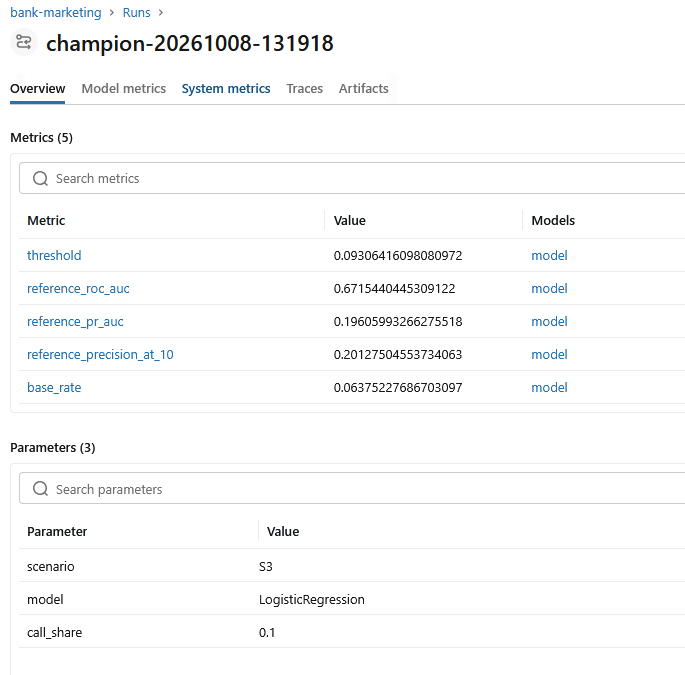

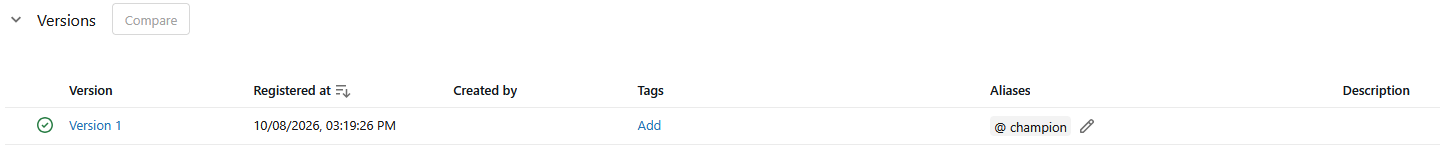

### 8.2 API de service

**Dépôt** : https://github.com/3ti3nne/certif_etienne, dossier `api/`.

| Route | Méthode | Rôle | Validation |
|---|---|---|---|
| `/health` | GET | Le service répond et le modèle est chargé, avec sa version | aucune entrée |
| `/predict` | POST | Probabilité de souscription, décision (`call`, `do_not_call`, `advisor_review`), seuil et version du modèle | Pydantic : 14 champs typés et bornés, tout champ inconnu est refusé (code 422) |
| `/feedback` | POST | Résultat de l'appel : `subscribed`, `declined`, `unreachable` ou `opted_out` | Pydantic |

Au démarrage, l'API compare ses champs aux variables du modèle et refuse de démarrer s'ils diffèrent. Un client opposé au démarchage reçoit un code 403. Chaque requête est journalisée en JSON avec Loguru : route, code retour, temps de réponse. Chaque prédiction l'est avec ses entrées, sa sortie, la version du modèle et l'horodatage. Le fichier de journaux tourne tous les 10 Mo et est gardé 1 an.

Le réentraînement passe par un script lancé par la CI. Une route `/train` permettrait à n'importe quelle requête de remplacer le modèle en production ; le script, lui, compare le modèle en place et le nouveau, et promeut le nouveau seulement s'il est meilleur et au moins aussi équitable.

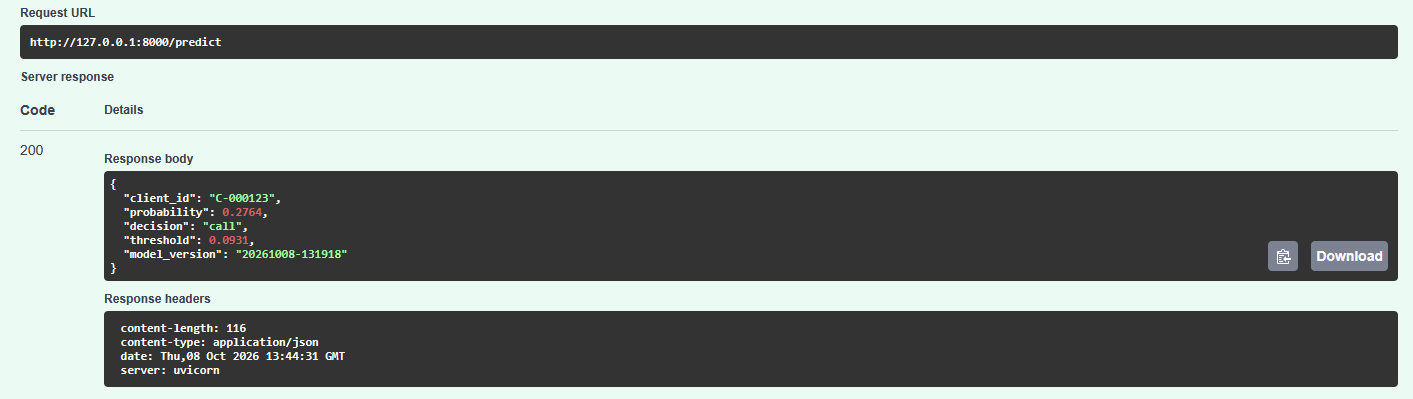

### 8.3 Interface utilisateur

Streamlit (`streamlit_app.py`), deux pages :
- **Should we call this client?** : le conseiller saisit un client et lit la probabilité et la décision. Ici, le client tombe dans la zone d'hésitation, la décision revient donc au conseiller.
- **Campaign dashboard** : santé du service (requêtes, erreurs, temps de réponse), activité commerciale (clients notés, part recommandée pour un appel, souscription réelle contre prédite) et stabilité des variables de conjoncture. Après l'envoi de 300 clients récents à l'API, 56 % sont recommandés au lieu des 10 % prévus et cinq variables sont en alerte rouge : la dérive se voit au premier coup d'œil.

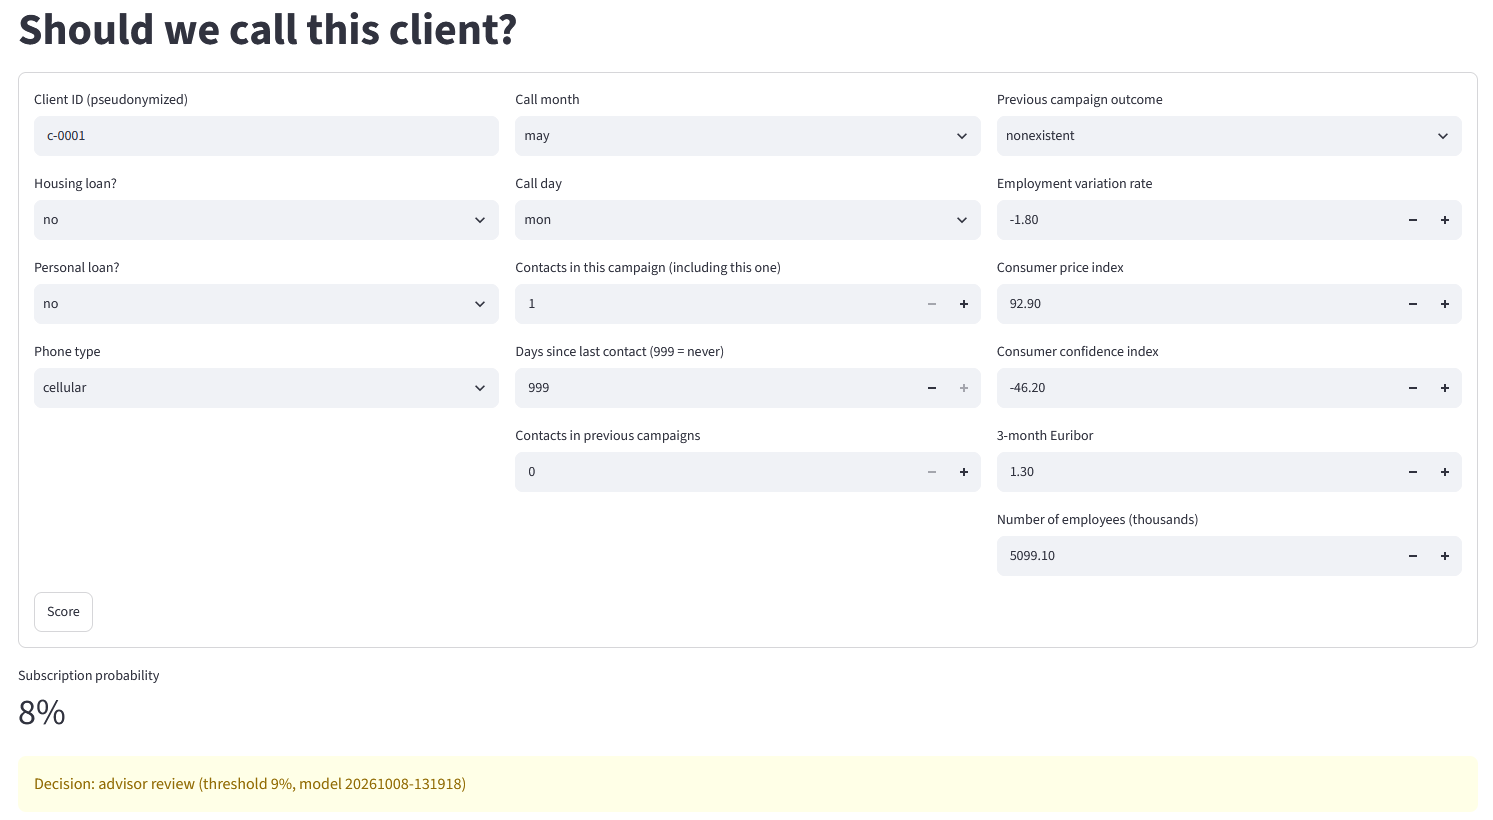

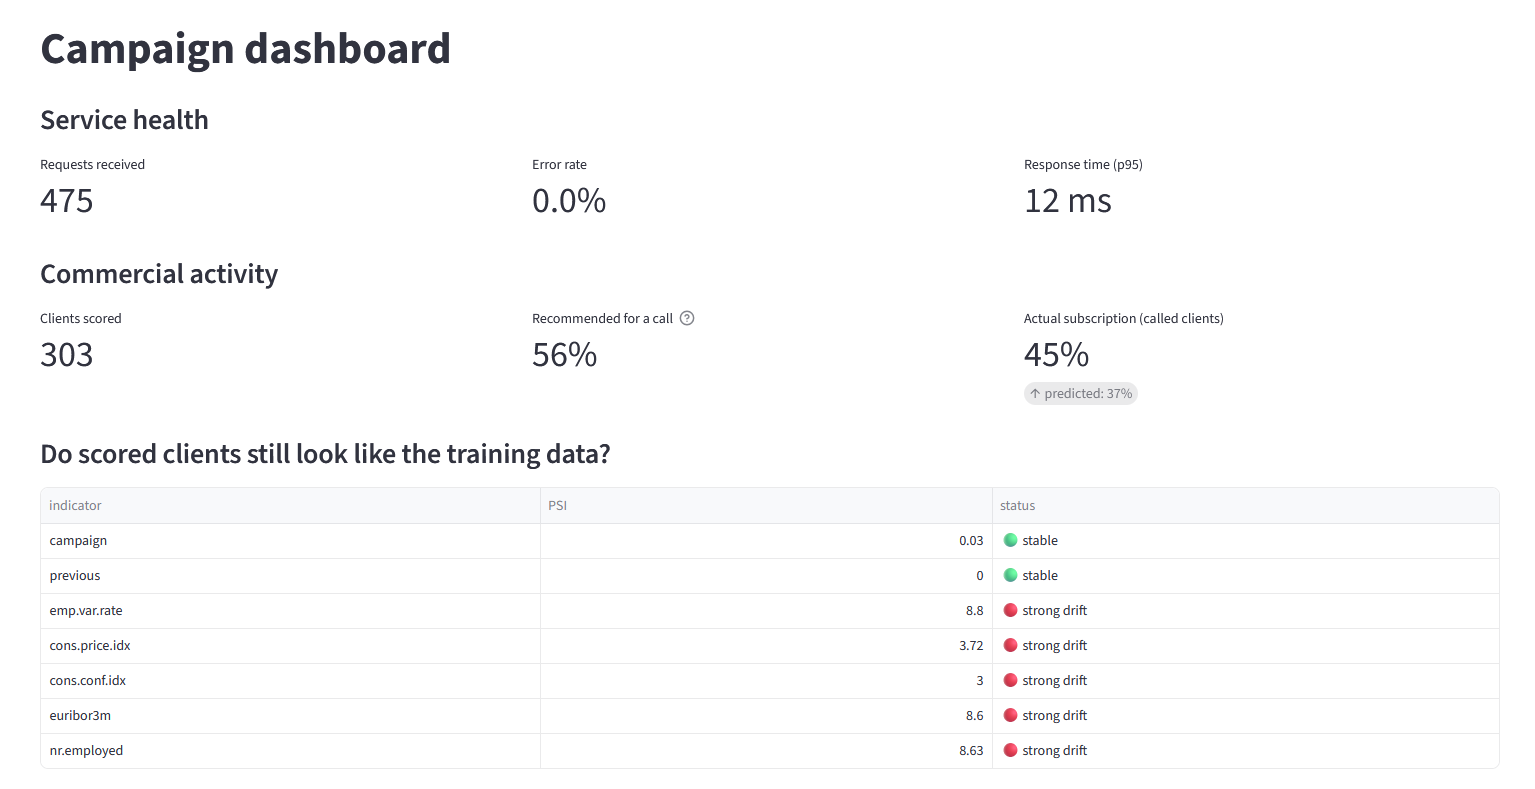

### 8.4 Schéma d'architecture

Légende : `[( )]` données · `[ ]` traitement · `([ ])` modèle · `{ }` décision · `( )` humain · `[/ /]` sortie · trait plein : flux normal · pointillés : exclusion ou renvoi au conseiller.

```mermaid
flowchart LR
    subgraph SI["SI de la banque"]
        CLI[("Clients et résultats<br/>des campagnes")]
        F{"Opposé au démarchage ?<br/>Déjà 4 appels ?"}
    end
    subgraph PF["Plateforme de scoring (serveur de la banque)"]
        B["Traitement de nuit :<br/>clients de la campagne"]
        API["API FastAPI<br/>/predict · /feedback · /health"]
        M(["Modèle champion"])
        Z{"Probabilité à moins<br/>de 0,02 du seuil ?"}
        LOG[("Journaux JSON, 1 an")]
    end
    subgraph H["Équipe commerciale"]
        C("Conseiller<br/>page Streamlit")
        L[/"Liste d'appels du lendemain"/]
    end
    subgraph SUIVI["Suivi et réentraînement"]
        D["Tableau de bord<br/>dérive, réel contre prédit"]
        CI["CI GitHub Actions<br/>tests, dérive, champion/challenger"]
        ML[("MLflow<br/>registre et alias champion")]
    end
    CLI --> F
    F -->|non| B --> API --> M --> Z
    F -.->|oui| X[/"Pas d'appel"/]
    Z -->|non| L
    Z -.->|oui| C
    C --> L
    L -->|résultat de l'appel| API
    API --> LOG --> D
    CLI -->|données récentes| CI
    CI --> ML
    ML -->|nouveau champion validé| M

    classDef data fill:#e5e7eb,stroke:#6b7280,color:#111
    classDef code fill:#ffffff,stroke:#6b7280,color:#111
    classDef ml fill:#bfdbfe,stroke:#1d4ed8,color:#111
    classDef dec fill:#fef08a,stroke:#a16207,color:#111
    classDef hum fill:#bbf7d0,stroke:#15803d,color:#111
    classDef out fill:#e9d5ff,stroke:#7e22ce,color:#111
    class CLI,LOG,ML data
    class B,API,D,CI code
    class M ml
    class F,Z dec
    class C hum
    class L,X out
```

**Lecture** : chaque soir, le SI de la banque écarte les clients opposés au démarchage ou déjà appelés 4 fois dans la campagne, puis envoie les autres à l'API. Les clients au-dessus du seuil forment la liste d'appels du lendemain ; ceux de la zone d'hésitation vont au conseiller, qui tranche. Le résultat de chaque appel revient par `/feedback`. Le tableau de bord lit les journaux de l'API, et la CI relance chaque lundi le contrôle de dérive et, si besoin, le réentraînement, avec MLflow comme registre. Le filtre et le traitement de nuit appartiennent au SI de la banque ; dans le dépôt, le script `scripts/simulate_production.py` joue ce rôle.

**Volontairement absents** : une base de données dédiée (un fichier de journaux suffit à ce volume), un orchestrateur ou Kubernetes (un seul conteneur), un GPU, une route `/train`.

**Hébergement : sur les serveurs de la banque.** L'API tient dans 126 Mo de mémoire et utilise moins de 1 % d'un processeur au repos. Les données clients restent dans le SI de la banque, et aucun contrat d'hébergeur n'est à négocier. Contrepartie : la banque exploite elle-même le conteneur (mises à jour de sécurité, sauvegardes, surveillance) ; une panne de quelques heures reste sans effet sur les appels du jour, la liste étant préparée la veille. Solution de repli si la banque manque de serveurs ou d'équipe pour exploiter un conteneur : un cloud souverain qualifié SecNumCloud (OVHcloud, Outscale). Un hébergeur américain, même en région européenne, reste soumis au CLOUD Act : il est écarté.

**Performance, coût et dimensionnement** :

| Critère | Mesure | Lecture |
|---|---|---|
| Latence | 12 ms au 95e centile sur 475 requêtes (tableau de bord) | La cible fixée au cadrage était 200 ms, et un conseiller tolère une seconde. Le traitement de nuit n'a aucune contrainte de temps |
| Mémoire | 126 Mo pour le conteneur en service | Mesurée après 50 prédictions |
| Calcul | 1 000 clients notés en 10 à 20 ms, soit 1 à 2 s pour 100 000 clients | Le coût d'inférence est négligeable ; le seul coût est le serveur, déjà présent chez la banque |
| Dimensionnement | 1 vCPU, 1 Go de RAM, 2 Go de disque (image de 671 Mo, journaux) | Large marge |
| Performance contre coût | La forêt aléatoire gagnerait 2 souscripteurs pour 100 appels, pour un modèle 4 000 fois plus lourd et 5 fois plus lent | La régression reste le meilleur rapport |

**Acteurs à consulter** :

| Acteur | Ce qu'il valide |
|---|---|
| DSI | Le serveur, l'intégration au SI : filtre, traitement de nuit, retour des résultats d'appel |
| RSSI | L'accès à l'API (réseau interne, authentification) et la protection des journaux |
| DPO | La base légale du démarchage, l'analyse d'impact, les durées de conservation |
| Conformité | Le respect de la loi sur le démarchage et le suivi de l'équité par tranche d'âge |
| Métier (responsable de campagne, conseillers) | La capacité d'appel (10 %), le plafond de 4 appels, la zone d'hésitation, la lisibilité du tableau de bord |

### 8.5 Conteneurisation & CI/CD

- **Docker** (`Dockerfile`) : image Python 3.12 qui ne contient que l'API, ses dépendances (`requirements-api.txt`, même version de scikit-learn qu'à l'entraînement) et le modèle. Elle pèse 671 Mo, et un contrôle interroge `/health` toutes les 30 s.
- **Tests** (`tests/`) : 20 tests pytest. Ils vérifient la recette (fuite et variables sensibles retirées, code « jamais contacté », modalité inconnue), les mesures (précision dans le top 10 %, équité, PSI), l'API (santé, prédiction, entrées refusées, journalisation, opposition) et les règles de promotion du réentraînement.
- **CI GitHub Actions** (`.github/workflows/ci.yml`), à chaque push, chaque lundi à 6 h ou à la demande :
  1. installation du projet et tests ;
  2. entraînement, avec un échec si la ROC-AUC tombe sous 0,65 ;
  3. contrôle de dérive et duel entre le modèle en place et un nouveau ;
  4. construction de l'image Docker et vérification que `/health` répond.

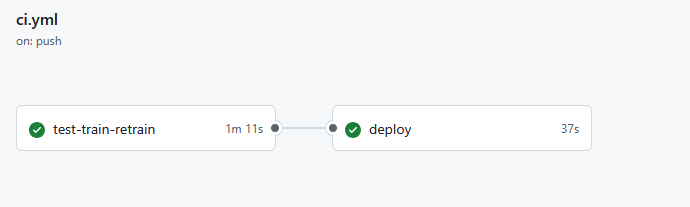

### 8.6 Synthèse industrialisation

**Pile retenue** : FastAPI et Pydantic (la validation des entrées et la documentation Swagger viennent des mêmes schémas), Loguru (journaux JSON relus par le tableau de bord), MLflow (historique des entraînements et registre avec l'étiquette `champion`, plus fiable qu'un fichier de suivi tenu à la main), Streamlit (tableau de bord écrit en Python), Docker et GitHub Actions.

**Choix d'architecture** : un seul conteneur léger sur les serveurs de la banque, nourri par un traitement de nuit, avec le conseiller dans la boucle pour les cas hésitants.

**Points encore ouverts** : l'authentification de l'API, à définir avec le RSSI ; le branchement du filtre et du traitement de nuit sur le SI réel ; le stockage des retours d'appel dans une base de la banque, à la place du fichier CSV.

---
## 9. Suivi en production & amélioration continue

**Compétences** : C8 (mesurer performance), C9 (amélioration continue)

### 9.1 Métriques à surveiller

Deux dérives à distinguer : les clients et la conjoncture changent (dérive des données), ou le lien entre leurs caractéristiques et la souscription change (dérive du concept). Pour les observer, on simule la production : le modèle servi, entraîné sur les 80 % de clients les plus anciens, est appliqué aux 20 % les plus récents. Cette simulation est indépendante de l'évaluation du modèle faite plus haut.

In [45]:
cut = int(len(df) * 0.8)
history, recent = df.iloc[:cut], df.iloc[cut:]
pd.Series({f: psi(history[f], recent[f]) for f in bank.NUMERIC if f in SCENARIOS["S3"]}).round(2).to_frame("PSI")

,PSI
campaign,0.03
previous,0.00
emp.var.rate,8.80
cons.price.idx,3.87
cons.conf.idx,2.95
euribor3m,8.60
nr.employed,8.63


In [46]:
production_model = build_pipeline(SCENARIOS["S3"], LogisticRegression(max_iter=1000)).fit(history, history["y"])
recent_scores = production_model.predict_proba(recent)[:, 1]
print(f"Mean predicted {recent_scores.mean():.3f} | actual {recent['y'].mean():.3f} | "
      f"ROC-AUC {roc_auc_score(recent['y'], recent_scores):.3f}")
calibration = pd.DataFrame({"Predicted": recent_scores, "Actual": recent["y"].values})
calibration["Decile"] = pd.qcut(calibration["Predicted"], 10, labels=False, duplicates="drop") + 1
calibration.groupby("Decile").mean().round(3).T

Mean predicted 0.241 | actual 0.308 | ROC-AUC 0.747


Decile,1,2,3,4,5,6,7,8,9,10
Predicted,0.041,0.064,0.077,0.091,0.124,0.180,0.237,0.320,0.516,0.762
Actual,0.074,0.092,0.154,0.122,0.285,0.341,0.354,0.483,0.622,0.562


- **Dérive des données** : les cinq variables de conjoncture ont un PSI entre 2,9 et 8,8, très au-dessus du seuil d'alerte de 0,2. Le nombre d'appels et l'historique des contacts restent stables.
- **Calibration** : le modèle annonce 24 % de souscriptions en moyenne, il y en a 31 %. Il sous-estime les tranches du milieu (12 à 32 % annoncés, 29 à 48 % réels) et surestime la meilleure (76 % annoncés, 56 % réels). Le classement tient encore (ROC-AUC 0,75) : les probabilités ont dérivé, l'ordre des clients reste bon.

| Type | Métrique | Seuil d'alerte | Source |
|---|---|---|---|
| Système | Temps de réponse au 95e centile | > 200 ms, la cible du cadrage | Journaux de l'API, tableau de bord |
| Système | Taux d'erreur (codes 5xx) | > 1 % sur une journée | Journaux de l'API, tableau de bord |
| Système | Disponibilité | `/health` en échec 3 fois de suite | Contrôle Docker toutes les 30 s |
| Données | PSI des variables du modèle (profil des clients notés) | > 0,2 : alerte ; de 0,1 à 0,2 : à surveiller | Tableau de bord, script de réentraînement |
| Modèle | ROC-AUC sur les clients dont on connaît le résultat | < référence - 0,05 | Script de réentraînement |
| Modèle | Écart entre souscription prédite et réelle | > 5 points | Tableau de bord, script de réentraînement |
| Métier | Part de clients recommandés pour un appel | Hors de 5 à 20 % (capacité prévue : 10 %) | Tableau de bord |
| Métier | Souscripteurs pour 100 appels | < 22,5, le critère de succès du cadrage | Retours `/feedback`, tableau de bord |
| Équité | Taux d'appel et appels inutiles par tranche d'âge, chaque mois | Écart qui grandit d'un mois à l'autre sans que l'écart de souscription suive | Journaux croisés avec l'âge dans le SI de la banque (l'API ne reçoit pas l'âge) |

### 9.2 Boucle de rétroaction

Après chaque appel, le conseiller enregistre le résultat par `/feedback` : souscrit, refusé, injoignable ou opposé. Une opposition exclut le client de tous les scorings suivants (code 403). Les résultats rejoignent les données de la campagne et servent au contrôle de dérive comme au prochain réentraînement.

**Biais de sélection** : on connaît le résultat des seuls clients appelés, c'est-à-dire ceux que le modèle a choisis. Réentraîné uniquement sur eux, il apprendrait de moins en moins sur les clients qu'il écarte. Parade : appeler à chaque campagne un petit échantillon tiré au hasard parmi les clients non retenus, par exemple 1 % de la liste, pour garder une mesure juste de ce qu'on manque.

### 9.3 Plan de réentraînement

**Déclencheurs** (`scripts/retrain.py`), vérifiés chaque lundi par la CI et après chaque campagne :
1. performance : ROC-AUC sur les nouveaux clients inférieure à la référence moins 0,05 ;
2. dérive : PSI supérieur à 0,2 sur une variable du modèle ;
3. calibration : écart de plus de 5 points entre souscription prédite et réelle.

**Validation avant mise en production** : quand un déclencheur s'allume, un nouveau modèle, le challenger, est entraîné sur l'historique et la première moitié des nouvelles données, puis comparé au modèle en place sur la seconde moitié. Il est promu seulement s'il a une meilleure PR-AUC **et** un disparate impact qui baisse de moins de 0,05. Les scores des deux modèles sont enregistrés dans MLflow ; en cas de promotion, l'ancien modèle est archivé et l'étiquette `champion` passe au nouveau.

**Sur la simulation** (sortie du script) : cinq dérives et un écart de calibration (24,1 % prédit contre 30,8 % réel) se déclenchent. Le challenger obtient une PR-AUC de 0,544 contre 0,557 pour le modèle en place : il est refusé.

**Revue périodique** : chaque trimestre, le responsable de campagne, la conformité et le DPO revoient les indicateurs, l'équité par tranche d'âge, la capacité d'appel et le plafond de 4 appels.

### 9.4 Robustesse en exploitation

La zone d'hésitation et la capacité d'appel, fixées pendant la conception, se surveillent en production. Avec le modèle servi, à son seuil de 0,093 :

In [47]:
history_scores = cross_val_predict(build_pipeline(SCENARIOS["S3"], LogisticRegression(max_iter=1000)), history,
                                   history["y"], cv=cv, method="predict_proba")[:, 1]
production_threshold = np.quantile(history_scores, 0.90)
print(f"Production threshold: {production_threshold:.3f}")
pd.DataFrame({"Recommended for a call": [(scores >= production_threshold).mean() for scores in [history_scores, recent_scores]],
              "In the grey zone": [(np.abs(scores - production_threshold) < 0.02).mean()
                                   for scores in [history_scores, recent_scores]]},
             index=["History", "Recent period"]).round(3)

Production threshold: 0.093


,Recommended for a call,In the grey zone
History,0.100,0.086
Recent period,0.633,0.222


Sur l'historique, 10 % des clients sont recommandés et 8,6 % tombent dans la zone d'hésitation : le seuil, bas, se trouve là où les scores sont serrés. Sur la période récente, ces parts passent à 63 % et 22 % : les deux alertes se déclenchent.

| Axe | Métrique opérationnelle | Action |
|---|---|---|
| **Entrées hors du domaine** | Valeurs hors des bornes de l'API (Pydantic) ; PSI des variables | Requête refusée (code 422) et journalisée ; alerte au tableau de bord et contrôle de dérive par la CI |
| **Dérive du seuil de rejet** | Part des clients en zone d'hésitation, part recommandée pour un appel | Alerte si l'une des deux double par rapport à l'historique. Le seuil est alors recalculé sur les scores de la campagne en cours, à la main aujourd'hui |
| **Calibration** | Souscription prédite contre réelle, par tranche de score, chaque mois | Écart de plus de 5 points : déclencheur de réentraînement. Si seul le niveau moyen dérive, on recale d'abord le seuil, plus rapide qu'un réentraînement complet |

### 9.5 Synthèse amélioration continue

**Cadence** : en continu pour la santé du service (tableau de bord, contrôle Docker) ; chaque lundi pour la dérive et le duel champion/challenger (CI) ; chaque mois pour la calibration et l'équité par tranche d'âge ; chaque trimestre, revue des indicateurs et des seuils avec le métier, la conformité et le DPO.

**Déclencheurs de réentraînement** : ROC-AUC en baisse de plus de 0,05, PSI supérieur à 0,2, écart de calibration de plus de 5 points.

**Remédiation** : recaler le seuil sur la campagne en cours ; réentraîner sur les données récentes ; promouvoir le nouveau modèle seulement s'il est meilleur et au moins aussi équitable, sinon garder l'ancien et alerter l'équipe data.

---
## Annexes

### A. Glossaire métier & technique

| Terme | Définition |
|---|---|
| PR-AUC | Aire sous la courbe précision-rappel. Résume en un nombre la capacité du modèle à placer les souscripteurs en tête de liste : elle vaut le taux de souscription (0,113) pour un classement au hasard et 1 pour un classement parfait |
| ROC-AUC | Probabilité qu'un souscripteur tiré au hasard reçoive un score plus élevé qu'un non-souscripteur : 0,5 au hasard, 1 pour un classement parfait |
| Précision dans le top 10 % | Part de souscripteurs parmi les 10 % de clients les mieux notés, autrement dit le nombre de souscriptions pour 100 appels |
| Rappel | Part des souscripteurs que le modèle fait appeler |
| F1, F1 macro | Moyenne harmonique de la précision et du rappel ; le F1 macro fait la moyenne des deux classes |
| Fuite de données | Variable qui contient une information indisponible au moment de la décision, ici la durée de l'appel |
| Validation croisée stratifiée | Le train est découpé en 5 parts qui gardent chacune 11,3 % de « yes » ; chaque part sert une fois à la validation |
| Test scellé | Les 20 % de clients mis de côté au départ, utilisés une seule fois pour évaluer le modèle retenu |
| Pipeline | Enchaînement de la préparation des données et du modèle, ajusté d'un seul bloc sur les données d'entraînement |
| One-hot | Transformation d'une variable catégorielle en autant de colonnes 0/1 que de modalités |
| Seuil d'appel | Score au-dessus duquel un client est appelé, fixé pour appeler 10 % des clients |
| Zone d'hésitation | Scores à moins de 0,02 du seuil d'appel : le client est renvoyé au conseiller |
| Calibration | Accord entre la probabilité annoncée et la fréquence réelle : si le modèle annonce 30 %, 30 % des clients souscrivent |
| Disparate impact | Taux d'appel d'un groupe divisé par celui du groupe le plus appelé ; la règle des 4/5 signale un écart sous 0,8 |
| Proxy | Variable conservée qui permettrait de deviner une variable retirée, par exemple l'âge |
| PSI | Population Stability Index : écart entre la distribution d'une variable à l'entraînement et en production. Au-dessus de 0,2, la dérive est forte |
| Dérive des données, dérive du concept | Les clients ou la conjoncture changent ; ou le lien entre leurs caractéristiques et la souscription change |
| Champion, challenger | Le modèle en production et un nouveau candidat, comparés sur les mêmes données récentes avant toute promotion |
| AIPD | Analyse d'impact relative à la protection des données, demandée par l'article 35 du RGPD pour les traitements à risque |

### B. Sources & bibliographie

- **Données** : UCI Machine Learning Repository, *Bank Marketing*, fichier `bank-additional-full.csv`, https://archive.ics.uci.edu/dataset/222/bank+marketing, licence CC BY 4.0.
- **Article d'origine des données** : Moro, S., Cortez, P. et Rita, P. (2014). *A data-driven approach to predict the success of bank telemarketing*. Decision Support Systems, 62, 22-31.
- **RGPD** : règlement (UE) 2016/679, articles 5, 6, 9, 13, 14, 21, 22 et 35.
- **Démarchage téléphonique** : loi n° 2025-594 du 30 juin 2025, consentement préalable à partir du 11/08/2026.
- **Discrimination** : Code pénal, articles 225-1 et 225-2.
- **AI Act** : règlement (UE) 2024/1689, annexe III (systèmes à haut risque).
- **Documentation technique** : scikit-learn, FastAPI, Pydantic, Loguru, MLflow, Streamlit, Docker, GitHub Actions.

### C. Décisions techniques détaillées

| Décision | Choix | Pourquoi | Chiffre clé |
|---|---|---|---|
| Environnement | `python -m venv` et pip, versions figées dans `requirements.txt` | Installation reproductible sur le poste et dans la CI | 20 tests verts dès la mise en place |
| Métrique principale | PR-AUC, plus la précision dans le top 10 % pour le métier | Classe rare et capacité d'appel limitée | 0,113 au hasard |
| Déséquilibre | Pas de pondération des classes : on appelle les 10 % de clients les mieux notés | Même classement, et des probabilités justes | 11 % annoncés en moyenne, contre 39 % avec pondération |
| Scénario | Sans la durée de l'appel ni les variables sensibles | Fuite retirée ; variables sensibles retirées sans perte | PR-AUC 0,451 avec ou sans elles |
| Modèle | Régression logistique | Lisible, légère et la plus stable dans le temps | 2 souscripteurs de moins pour 100 appels que le boosting ; 6 Ko |
| Modèle de production | Entraîné sur les 80 % de clients les plus anciens | Les 20 % récents simulent la production et éprouvent la surveillance | Taux de souscription de 6,4 % sur l'historique, 31 % sur la période récente |
| Garde-fou de la CI | ROC-AUC d'au moins 0,65 | La ROC-AUC reste comparable d'une période à l'autre ; la PR-AUC suit le taux de souscription | 0,672 sur l'historique |
| Zone d'hésitation | ±0,02 autour du seuil, renvoyée au conseiller | Le seuil varie lui-même d'environ 0,02 selon les données d'entraînement | 1,6 % des clients du test |
| Écart d'appel par âge | Accepté sous trois garde-fous : refus respecté, 4 appels au plus par campagne, suivi mensuel | L'écart passe par la période, qui repère les seniors (ROC-AUC 0,87), et suit un intérêt réel : un appel aboutit aussi souvent quel que soit l'âge. Le corriger obligerait à réutiliser l'âge | Seniors appelés à 56 %, 30-59 ans à 7 % ; 51 % de souscripteurs parmi les seniors appelés, 47 à 50 % ailleurs |

### D. Journal de bord

## Jour 1 (14/09/2026)

### Étapes / Actions réalisées
- Sujet découpé en 26 exigences ; cadre étudié : RGPD, loi 2025-594 sur le démarchage, AI Act.
- Prototype complet en bac à sable : 4 scénarios × 3 modèles, API, réentraînement, Docker, MLflow, Streamlit, 20 tests.

### Observations / Difficultés
- Fuite repérée : `duration` n'est connue qu'après l'appel (ROC-AUC 0,934 → 0,790 sans elle).
- 8 décisions recommandées dans la spec, chiffres à l'appui (métrique, déséquilibre, scénario, modèle…), à trancher une par une.

### Prochaines étapes
- Questions à la formation (date du ZIP, durée de soutenance), puis mise en place du dépôt.

## Jour 2 (18/09/2026)

### Étapes / Actions réalisées
- Mise en place : environnement, dépôt GitHub public, 20 tests verts, CI verte dès le premier run.
- Rédaction du cadrage et du brief de soutenance.

### Observations / Difficultés

### Prochaines étapes
- Relire et commiter le cadrage, puis données et EDA.

## Jour 3 (23/09/2026)

### Étapes / Actions réalisées
- Données : source, chargement, dictionnaire des 21 variables avec une colonne « connue avant l'appel ? ».
- EDA : qualité, distributions, cible, effet du temps, biais par groupe, synthèse. Tous les chiffres attendus sont reproduits.

### Observations / Difficultés
- Qualité : 12 doublons supprimés avant le split, pour qu'une même ligne ne tombe pas à la fois dans le train et dans le test. Les `unknown` restent une modalité, `pdays = 999` veut dire « jamais contacté ».
- Fuite confirmée : `duration = 0` donne toujours « no ». Cible déséquilibrée : 11,3 % de « yes », l'accuracy est écartée.
- Le taux de souscription passe de 2,8 % à 46 % pendant que l'Euribor chute (crise de 2008) : test de robustesse dans le temps à prévoir.
- Biais : 39,6 % de souscription chez les 60 ans et plus, 31,4 % chez les étudiants, 6,9 % chez les ouvriers.

### Prochaines étapes
- Préparation des données : split stratifié 80/20 avec le test scellé, pipeline, scénarios, assertions.

## Jour 4 (01/10/2026)

### Étapes / Actions réalisées
- Préparation : découpage 80/20 stratifié avec le test scellé, recette de préparation, 4 scénarios justifiés, assertions de qualité.
- Revue de la démarche : ajout d'un plancher, du boosting à la place de l'arbre, de 3 réglages par modèle, d'un test de robustesse dans le temps et du coût mesuré.
- Modélisation : 4 scénarios × 3 modèles et un plancher en validation croisée, comparaison pli par pli, robustesse dans le temps, réglages.
- **Passe test n° 1, unique** : régression logistique sans variables sensibles. 51 souscripteurs pour 100 appels contre 11 au hasard, PR-AUC 0,455, ROC-AUC 0,802.

### Observations / Difficultés
- `default` rejoint les variables sensibles : elle touche à la vulnérabilité économique et n'apporte rien (PR-AUC 0,451 avec ou sans).
- Métrique : PR-AUC en principal et précision dans le top 10 % pour le métier, parce que le centre d'appels ne peut appeler qu'une partie des clients.
- Pas de pondération des classes : essayée en premier, elle classe pareil mais annonce 39 % de chances au lieu de 11 %.
- Scénario sans variables sensibles : les retirer ne coûte rien.
- Régression logistique : la forêt et le boosting gagnent environ 2 souscripteurs pour 100 appels, mais la régression tient mieux dans le temps, se lit par ses coefficients et pèse 6 Ko.
- Difficulté : le test de robustesse dans le temps prévu au départ touchait des lignes du test scellé. Corrigé en le faisant sur le train seul.

### Prochaines étapes
- Retoucher les sections déjà faites après la revue de la démarche : EDA, dictionnaire, préparation, cadrage, sources.
- Arbitrage, équité et RGPD.

## Jour 5 (08/10/2026)

### Étapes / Actions réalisées
- Arbitrage : tableau comparatif de 6 combinaisons scénario × modèle (coût, latence, explicabilité, biais), équité mesurée par tranche d'âge et par métier avec et sans variables sensibles, réponses aux questions RGPD et AI Act.
- Industrialisation lancée et vérifiée : entraînement suivi dans MLflow, API, réentraînement (challenger refusé), tableau de bord, Docker, CI verte. Six captures intégrées au notebook.
- Interprétation, architecture et suivi en production rédigés : importance des variables, analyse des erreurs et filet de sécurité, schéma, hébergement, dimensionnement, indicateurs et plan de réentraînement.
- Relecture complète : phrases reformulées, cible du modèle alignée sur une PR-AUC d'au moins 0,23, dictionnaire corrigé, licence des données ajoutée.

### Observations / Difficultés
- Retirer les variables sensibles change peu les écarts d'appel : les 60 ans et plus sont appelés à 56 %, les 30-59 ans à 7 %. Le modèle ne devine pas l'âge ; l'écart vient de la période, puisque 71 % des seniors ont été contactés dans le dernier cinquième des données.
- Écart accepté sous trois garde-fous qui n'utilisent pas l'âge : refus respecté, 4 appels au plus par campagne, suivi mensuel par tranche d'âge. Le corriger obligerait à remettre l'âge dans la décision.
- Le chiffre de 51 souscripteurs pour 100 appels mélange les périodes. À l'intérieur d'une même période, le modèle multiplie le taux de réussite par 2 à 4 quand la conjoncture est correcte, et fait jeu égal avec le hasard dans les périodes creuses. Écrit tel quel dans le notebook et dans les messages au client.
- Plafond de 4 appels : 13 % des clients souscrivent au premier appel, 3 à 8 % à partir du cinquième.
- Hébergement sur les serveurs de la banque : l'API tient dans 126 Mo de mémoire et les données clients restent chez la banque.
- Simulation de production : 63 % des clients recommandés au lieu de 10 %, probabilités sous-estimées (24 % annoncés, 31 % réels). Les alertes du tableau de bord et du réentraînement se déclenchent comme prévu.

### Prochaines étapes
- Finaliser et rendre le dossier.
- Slides et répétition de la soutenance.

## Jour 6 (09/10/2026)

### Étapes / Actions réalisées
- Slides de la soutenance générées à partir du notebook final : 17 slides et 6 annexes, chiffres et captures vérifiés.
- Vérification sur l'âge revue : la mesure d'exactitude sur quatre tranches d'âge est remplacée par le ROC-AUC des 60 ans et plus contre le reste, avec et sans les variables de période.
- Tableaux d'équité complétés par la part des appels et la précision de chaque groupe, ajoutées à la recette commune avec leur test.
- Verdict sur l'écart d'âge, annexe C et message au client réécrits. Slide ajoutée sur nos choix et ce qu'un entretien client aurait changé.

### Observations / Difficultés
- Les seniors ne font que 3 % du train : la mesure d'exactitude du jour 5 ne pouvait pas les voir. Mesurées directement, les variables du modèle les repèrent bien (ROC-AUC 0,87), presque entièrement grâce à la période (0,88 avec les seules variables de période, 0,67 sans). L'âge est absent du modèle, mais la période sert de proxy.
- Un appel aboutit aussi souvent quel que soit l'âge : 51 % des seniors appelés souscrivent, contre 47 à 50 % dans les autres tranches. L'écart pèse sur les seniors pas intéressés : 45 % sont appelés pour rien, contre 4 % entre 30 et 59 ans.
- Verdict maintenu (écart accepté sous les trois mêmes garde-fous), avec cet argument réécrit. Le corriger obligerait toujours à remettre l'âge dans la décision.
- Les 51 souscripteurs pour 100 appels supposent des conseillers et une offre comparables à 2008-2010 : le modèle choisit qui appeler, la vente reste le travail du conseiller. Ajouté au message au client.

### Prochaines étapes
- Envoyer le notebook, le journal et les slides.
- Répéter la soutenance et les questions probables du jury.